<a href="https://colab.research.google.com/github/IntelligentSystemsProject/Stock-Market-Project/blob/Reevaluate-Updated-Models-and-Plotting-Function/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Run this cell to install all required libraries for the project so subsequent code cells execute correctly.

In [16]:
!pip install kagglehub[pandas-datasets] matplotlib scikit-learn openpyxl statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

## Part 1: Data Cleaning and Feature Engineering

### 1.1 Dataset Cleaning function

This function standardizes diverse financial and economic datasets into a consistent, numeric time‑series format by detecting source‑specific quirks (e.g., WSTS wide‑format Excel, exchange rate CSVs, stock data) and enforcing clean date indices, ensuring reproducibility, comparability, and robustness for downstream modeling.


In [18]:
import pandas as pd
import numpy as np

def clean_and_prepare_timeseries(data, features=None, target="adj_close"):

    def log(stage, before, after):
        print(f"[{stage}] {before} → {after} (Δ {after - before})")

    # 1. LOAD DATA
    if isinstance(data, str):
        if data.endswith(".xlsx"):
            df = pd.read_excel(data, engine="openpyxl")
        else:
            df = pd.read_csv(data)
        file_path = data
    else:
        df = data.copy()
        file_path = "dataframe"

    initial_rows = len(df)
    print(f"\n[DATA LOAD] Initial rows: {initial_rows}")

    # 2. WSTS SPECIAL HANDLING
    if "wsts" in file_path.lower():

        print("[WSTS MODE ACTIVATED]")

        # Load raw file again cleanly
        df = pd.read_excel(file_path, engine="openpyxl")

        # Remove header rows
        df = df.drop([0, 1, 2]).reset_index(drop=True)

        # Rename columns
        df = df.rename(columns={
            '36 Years WSTS Blue Book Data': 'Year/Area',
            'Unnamed: 1': 'January',
            'Unnamed: 2': 'February',
            'Unnamed: 3': 'March',
            'Unnamed: 4': 'April',
            '1986 to Date': 'May',
            'Unnamed: 6': 'June',
            'Unnamed: 7': 'July',
            'Unnamed: 8': 'August',
            'Unnamed: 9': 'September',
            'Unnamed: 10': 'October',
            'Unnamed: 11': 'November',
            'Unnamed: 12': 'December',
            'Unnamed: 13': 'Total Year',
            'Unnamed: 14': 'Q1',
            'Unnamed: 15': 'Q2',
            'Unnamed: 16': 'Q3',
            'Unnamed: 17': 'Q4'
        })

        df.columns = df.columns.str.strip()

        # Extract years
        years = []
        for i in range(len(df)):
            if i % 6 == 0:
                years.append(df.loc[i, "Year/Area"])

        # Keep Worldwide only
        df_clean = df[df["Year/Area"] == "Worldwide"].copy()
        df_clean.reset_index(drop=True, inplace=True)

        df_clean.rename(columns={"Year/Area": "Area"}, inplace=True)

        df_clean["Year"] = pd.Series(years)
        df_clean["Year"] = df_clean["Year"].ffill()

        # Remove unwanted columns
        df_clean.drop(columns=[
            "Area",
            "Q1","Q2","Q3","Q4",
            "Total Year"
        ], inplace=True)

        # Drop incomplete year
        df_clean = df_clean.dropna(subset=["February"]).reset_index(drop=True)

        # Wide → Long
        df_long = df_clean.melt(
            id_vars=["Year"],
            var_name="Month",
            value_name="billings"
        )

        # Create datetime index
        df_long["date"] = pd.to_datetime(
            df_long["Year"].astype(str) + "-" + df_long["Month"],
            format="%Y-%B"
        )

        df_long = df_long[["date", "billings"]]
        df_long.sort_values("date", inplace=True)

        # Remove 2026+
        before = len(df_long)
        df_long = df_long[df_long["date"].dt.year < 2026]
        log("WSTS DROP 2026+", before, len(df_long))

        df_long.set_index("date", inplace=True)

        df = df_long

    # 3. STANDARD DATASETS
    else:
        df.columns = df.columns.str.strip().str.lower()

        df = df.rename(columns={
            "observation_date": "date",
            "dexjpus": "price",
            "wti_price_usd": "price"
        })

        if "date" not in df.columns:
            raise ValueError(f"No date column. Columns: {df.columns}")

        df["date"] = pd.to_datetime(df["date"], errors="coerce")

        before = len(df)
        df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
        print(f"[DATE CLEAN] {before} → {len(df)}")

    # 4. NUMERIC CLEANING
    df = df.apply(pd.to_numeric, errors="coerce")

    if "open" in df.columns:
        df["open"] = df["open"].replace(0, np.nan).ffill().bfill()

    before = len(df)
    df = df.ffill()
    print(f"[FILL NA] {before} → {len(df)}")

    if len(df) == 0:
        raise ValueError("Empty dataset after cleaning")

    # 5. FEATURE SELECTION
    if features is None:
        cols = set(df.columns)

        if {"open","close"}.issubset(cols):
            features = [c for c in ["open","high","low","close","adj_close","volume"] if c in cols]

        elif "price" in cols:
            features = ["price"]

        elif "billings" in cols:
            features = ["billings"]

        else:
            raise ValueError(f"No usable features. Columns: {df.columns}")

    features = [f.strip().lower() for f in features]
    target = target.strip().lower()

    if target not in features:
        raise ValueError(f"Target '{target}' not in features {features}")

    target_index = features.index(target)

   # 6. FINAL OUTPUT
    data_values = df[features].values

    final_rows = len(df)

    print(f"\nDataset: {file_path}")
    print(f"Initial rows: {initial_rows}")
    print(f"Final rows: {final_rows}")
    print(f"Dropped total: {initial_rows - final_rows}")
    print(f"Shape: {df.shape}")
    print(f"Features: {features}")
    print(f"Data shape: {data_values.shape}")
    print("-"*50)

    return df, data_values, target_index

### 1.2 Load Datasets

#### 1.2.1 Load Main Datasets

We sourced NVIDIA, Exxon, and Toyota stock data directly from KaggleHub. These curated datasets provide standardized OHLCV structures, making them ideal baselines for time‑series modeling and ensuring consistency when integrated with more irregular economic series.


In [19]:
# Load raw DataFrames from KaggleHub
import kagglehub
from kagglehub import KaggleDatasetAdapter

# NVIDIA
nvda_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "meharshanali/nvidia-stocks-data-2025",
    "NVDA.csv"
)

# Exxon
exxon_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "umerhaddii/exxon-mobil-stock-price-data",
    "exxon_stock_data.csv"
)

# Toyota
toyota_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "umerhaddii/toyota-stock-data-2025",
    "TM_1980-01-01_2025-06-27.csv"
)

print("NVIDIA:", nvda_raw.head())
print("Exxon:", exxon_raw.head())
print("Toyota:", toyota_raw.head())


NVIDIA:          Date  Adj Close     Close      High       Low      Open      Volume
0  1999-01-22   0.037615  0.041016  0.048828  0.038802  0.043750  2714688000
1  1999-01-25   0.041556  0.045313  0.045833  0.041016  0.044271   510480000
2  1999-01-26   0.038331  0.041797  0.046745  0.041146  0.045833   343200000
3  1999-01-27   0.038212  0.041667  0.042969  0.039583  0.041927   244368000
4  1999-01-28   0.038092  0.041536  0.041927  0.041276  0.041667   227520000
Exxon:          Date       Open       High        Low      Close  Adj Close    Volume
0  2015-01-02  92.250000  93.050003  91.809998  92.830002  61.023277  10220400
1  2015-01-05  92.099998  92.400002  89.500000  90.290001  59.353565  18502400
2  2015-01-06  90.239998  91.410004  89.019997  89.809998  59.038017  16670700
3  2015-01-07  90.650002  91.480003  90.000000  90.720001  59.636223  13590700
4  2015-01-08  91.250000  92.269997  91.000000  92.230003  60.628857  15487500
Toyota:          date                open        

#### 1.2.2 Load Exxon Mobil Auxilary dataset

In [20]:
import pandas as pd
import requests
from io import StringIO

wti_url = "https://eco3min.fr/dataset/wti-crude-oil.csv"

# Add a browser-like User-Agent so the server allows the request
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(wti_url, headers=headers)

# Convert the response text into a file-like object
wti_raw = pd.read_csv(StringIO(response.text))
print(wti_raw.head())


         date  wti_price_usd
0  1986-01-02          25.56
1  1986-01-03          26.00
2  1986-01-06          26.53
3  1986-01-07          25.85
4  1986-01-08          25.87


#### 1.2.3 Load Nvidia Auxilary dataset

In [21]:
import pandas as pd

# WSTS Billings (Excel)
wsts_url = "https://www.wsts.org/esraCMS/extension/media/f/WST/7531/WSTS-Historical-Billings-Report-Feb_2026.xlsx"
wsts_raw = pd.read_excel(wsts_url, engine="openpyxl")
print(wsts_raw.head())


                36 Years WSTS Blue Book Data Unnamed: 1 Unnamed: 2 Unnamed: 3  \
0  © 2025 By WSTS, Inc. All Rights Reserved.        NaN        NaN        NaN   
1               All numbers are in 1000 US$.        NaN        NaN        NaN   
2                                        NaN    January   February      March   
3                                       1986        NaN        NaN        NaN   
4                                   Americas     555850     633465     756220   

  Unnamed: 4 1986 to Date Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  \
0        NaN          NaN        NaN        NaN        NaN        NaN   
1        NaN          NaN        NaN        NaN        NaN        NaN   
2      April          May       June       July     August  September   
3        NaN          NaN        NaN        NaN        NaN        NaN   
4     689470       718336     797014     707784     697506     803392   

  Unnamed: 10 Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14 Unnamed: 15 

#### 1.2.4 Load Toyota Auxilary dataset

In [22]:
import pandas as pd

dex_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXJPUS"
dex_raw = pd.read_csv(dex_url)

print(dex_raw.head())


  observation_date  DEXJPUS
0       1971-01-04   357.73
1       1971-01-05   357.81
2       1971-01-06   357.86
3       1971-01-07   357.87
4       1971-01-08   357.82


### 1.3 Clean Datasets

In [23]:
nvda_df,   nvda_data,   nvda_target_idx   = clean_and_prepare_timeseries(nvda_raw,   features=["open","high","low","close","volume"],              target="close")
exxon_df,  exxon_data,  exxon_target_idx  = clean_and_prepare_timeseries(exxon_raw,  features=["open","high","low","close","volume"],              target="close")
toyota_df, toyota_data, toyota_target_idx = clean_and_prepare_timeseries(toyota_raw, features=["open","high","low","close","adj_close","volume"], target="adj_close")
wsts_df,   wsts_data,   wsts_target_idx   = clean_and_prepare_timeseries(wsts_url,   features=["billings"],                                        target="billings")
wti_df,    wti_data,    wti_target_idx    = clean_and_prepare_timeseries(wti_raw,    features=["price"],                                           target="price")
dex_df,    dex_data,    dex_target_idx    = clean_and_prepare_timeseries(dex_raw,    features=["price"],                                           target="price")



[DATA LOAD] Initial rows: 6558
[DATE CLEAN] 6558 → 6558
[FILL NA] 6558 → 6558

Dataset: dataframe
Initial rows: 6558
Final rows: 6558
Dropped total: 0
Shape: (6558, 6)
Features: ['open', 'high', 'low', 'close', 'volume']
Data shape: (6558, 5)
--------------------------------------------------

[DATA LOAD] Initial rows: 2388
[DATE CLEAN] 2388 → 2388
[FILL NA] 2388 → 2388

Dataset: dataframe
Initial rows: 2388
Final rows: 2388
Dropped total: 0
Shape: (2388, 6)
Features: ['open', 'high', 'low', 'close', 'volume']
Data shape: (2388, 5)
--------------------------------------------------

[DATA LOAD] Initial rows: 11414
[DATE CLEAN] 11414 → 11413
[FILL NA] 11413 → 11413

Dataset: dataframe
Initial rows: 11414
Final rows: 11413
Dropped total: 1
Shape: (11413, 6)
Features: ['open', 'high', 'low', 'close', 'adj_close', 'volume']
Data shape: (11413, 6)
--------------------------------------------------

[DATA LOAD] Initial rows: 249
[WSTS MODE ACTIVATED]
[WSTS DROP 2026+] 492 → 480 (Δ -12)
[FIL

#### 1.3.1 Datasets after Cleaning

In [24]:
def arrays_to_df(data_array, features, cleaned_df):
    # Reconstruct a clean DataFrame from the numpy array output using the already-cleaned df's index
    return pd.DataFrame(data_array, index=cleaned_df.index[:len(data_array)], columns=features)

# Reconstruct each dataset as a DataFrame
nvda_table = arrays_to_df(nvda_data, ["open","high","low","close","volume"], nvda_df)
exxon_table = arrays_to_df(exxon_data, ["open","high","low","close","volume"], exxon_df)
toyota_table = arrays_to_df(toyota_data, ["open","high","low","close","adj_close","volume"], toyota_df)
wsts_table = arrays_to_df(wsts_data, ["billings"], wsts_df)
wti_table = arrays_to_df(wti_data, ["price"], wti_df)
dex_table = arrays_to_df(dex_data, ["price"], dex_df)

# Print as tables
for name, tbl in [("NVDA", nvda_table), ("Exxon", exxon_table), ("Toyota", toyota_table),
                  ("WSTS", wsts_table), ("WTI", wti_table), ("DEX", dex_table)]:
    print(f"\n===== {name} =====")
    print(tbl.head(10).to_string())
    print(f"Shape: {tbl.shape}")
    print("-" * 50)


===== NVDA =====
                open      high       low     close        volume
date                                                            
1999-01-22  0.043750  0.048828  0.038802  0.041016  2.714688e+09
1999-01-25  0.044271  0.045833  0.041016  0.045313  5.104800e+08
1999-01-26  0.045833  0.046745  0.041146  0.041797  3.432000e+08
1999-01-27  0.041927  0.042969  0.039583  0.041667  2.443680e+08
1999-01-28  0.041667  0.041927  0.041276  0.041536  2.275200e+08
1999-01-29  0.041536  0.041667  0.039583  0.039583  2.440320e+08
1999-02-01  0.039583  0.040625  0.039583  0.040365  1.547040e+08
1999-02-02  0.039583  0.040625  0.036068  0.037240  2.640960e+08
1999-02-03  0.036719  0.038542  0.036458  0.038021  7.512000e+07
1999-02-04  0.038542  0.041146  0.038021  0.040104  1.819200e+08
Shape: (6558, 5)
--------------------------------------------------

===== Exxon =====
                 open       high        low      close      volume
date                                            

In [25]:
from sklearn.model_selection import TimeSeriesSplit

# Copy the cleaned NVIDIA dataset into a new variable
data = nvda_table.copy()

# Convert the DataFrame into a raw NumPy array for model input
data_raw = data.values

# Extract the list of feature column names
features = list(nvda_table.columns)

# Identify the index position of the target column ("close") in the feature list
target_index = features.index('close')

# Define the sliding window size (number of past days used to predict the next day)
window_size = 10

# Define the number of cross-validation splits for time-series data
n_splits = 5

# Configure time-series cross-validation (preserves temporal order, no shuffling)
tscv = TimeSeriesSplit(n_splits=n_splits)

# Print confirmation of the configuration
print(f"TimeSeriesSplit configured: {n_splits} folds, window_size={window_size}")


TimeSeriesSplit configured: 5 folds, window_size=10


## Part 2: Cross-Validation Helper Functions

In [26]:
def make_windows(scaled_arr, ws, ti):
    """Sliding-window features + target from a scaled numpy array."""
    X, y = [], []
    for i in range(len(scaled_arr) - ws):
        X.append(scaled_arr[i:i+ws].flatten())
        y.append(scaled_arr[i+ws][ti])
    return np.array(X), np.array(y)

def inv_scale(preds, sc, ti):
    """Inverse-scale predictions back to dollar values."""
    tmp = np.zeros((len(preds), sc.n_features_in_))
    tmp[:, ti] = preds
    return sc.inverse_transform(tmp)[:, ti]

print("Helper functions defined.")


Helper functions defined.


## Part 2.1 : Visualization Helper Function

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(results, title="Actual vs Predicted", max_points=300):
    """
    Plots actual vs predicted values from your CV models.

    Parameters:
    - results: dict returned from your training functions
    - title: plot title
    - max_points: limits plot size for readability
    """

    # Extract predictions
    y_true, y_pred = results["all_preds"]

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Optional trimming for readability
    if len(y_true) > max_points:
        step = len(y_true) // max_points
        y_true = y_true[::step]
        y_pred = y_pred[::step]

    plt.figure(figsize=(12, 5))

    plt.plot(y_true, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linewidth=2, linestyle="--")

    plt.title(title)
    plt.xlabel("Time Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

    plt.show()

In [28]:
def print_cv_summary(results, name="Model"):

    df = results["cv_df"]

    print(f"\n===== {name} CV SUMMARY =====")
    print(df.round(4))

    print("\nMeans:")
    print(f"MAE  : {results['mean_mae']:.4f}")
    print(f"RMSE : {results['mean_rmse']:.4f}")
    print(f"R2   : {results['mean_r2']:.4f}")

    # NEW: Standard deviation section
    std_mae  = df["MAE"].std()
    std_rmse = df["RMSE"].std()
    std_r2   = df["R2"].std()

    print("\nStd:")
    print(f"MAE  : {std_mae:.4f}")
    print(f"RMSE : {std_rmse:.4f}")
    print(f"R2   : {std_r2:.4f}")

## PART 3 Feature Enginneering

### 3.1 NVIDIA Feature Enginneering

Resampling with Lagged Signals

In [ ]:
def add_wsts_growth_aux(
    stock_table,
    wsts_table,
    feature_names,
    target_name="close",
    growth_periods=12,
    resample_rule="B",   # use business days for consistency
    lags=(30, 60, 90)
):
    """
    Adds WSTS growth-rate auxiliary features to NVDA dataset.
    """

    stock = stock_table.copy()
    wsts = wsts_table.copy()

    # Compute growth rate
    wsts["wsts_growth"] = wsts["billings"].pct_change(growth_periods)
    wsts = wsts[["wsts_growth"]].dropna()

    # Resample to business days
    wsts = wsts.resample(resample_rule).ffill()

    # Merge
    merged = stock.join(wsts, how="inner")
    merged["wsts_growth"] = merged["wsts_growth"].ffill()

    # Lagged signals
    new_features = []
    for lag in lags:
        col = f"wsts_growth_lag_{lag}"
        merged[col] = merged["wsts_growth"].shift(lag)
        new_features.append(col)

    # Cleaning
    rows_before = len(merged)
    merged = merged.replace([np.inf, -np.inf], np.nan).dropna()
    rows_after = len(merged)

    print(f"Rows before cleaning: {rows_before}")
    print(f"Rows after cleaning:  {rows_after}")
    print(f"Total rows dropped:   {rows_before - rows_after}")
    print("\nColumns:", merged.columns.tolist())
    print(f"\nFinal shape: {merged.shape}")

    # Update features + target index
    updated_features = feature_names.copy()
    updated_features.extend(new_features)
    target_index = updated_features.index(target_name)
    
    return merged, updated_features, target_index


In [86]:
# Apply NVDA + WSTS feature engineering
merged_nvda_df, features_nvda, nvda_target_idx = add_wsts_growth_aux(
    stock_table=nvda_table,
    wsts_table=wsts_table,
    feature_names=list(nvda_table.columns),
    target_name="close",
    growth_periods=12,   # year-over-year semiconductor demand
    lags=(30, 60, 90)    # delayed macro impact
)


Rows before cleaning: 2515
Rows after cleaning:  2425
Total rows dropped:   90

Columns: ['open', 'high', 'low', 'close', 'volume', 'wsts_growth', 'wsts_growth_lag_30', 'wsts_growth_lag_60', 'wsts_growth_lag_90']

Final shape: (2425, 9)


### 3.2 Exxon Feature Engineering 

In [31]:
import pandas as pd
import numpy as np

# 1. Date filtering
start_date = "2015-01-02"
end_date   = "2025-06-26"

exxon_table = exxon_table.loc[start_date:end_date].copy()
wti_table   = wti_table.loc[start_date:end_date].copy()

# 2. Drop duplicate date columns
if 'date' in exxon_table.columns:
    exxon_table = exxon_table.drop(columns=['date'])

if 'date' in wti_table.columns:
    wti_table = wti_table.drop(columns=['date'])

# 3. Ensure datetime index
exxon_table.index = pd.to_datetime(exxon_table.index)
wti_table.index   = pd.to_datetime(wti_table.index)

# 4. Resample WTI to business days
wti_table = wti_table.resample('B').ffill()

# 5. Merge
merged_exxon_df = exxon_table.join(
    wti_table[['price']].rename(columns={'price': 'wti_price'}),
    how='inner'
)

# FEATURE ENGINEERING

# Oil log returns captures short-term percentage changes in oil prices
merged_exxon_df['oil_log_return'] = np.log(
    merged_exxon_df['wti_price'] / merged_exxon_df['wti_price'].shift(1)
)

# Moving averages capture short-term (5-day) and medium-term (20-day) oil price trends
merged_exxon_df['oil_ma_5']  = merged_exxon_df['wti_price'].rolling(5).mean()
merged_exxon_df['oil_ma_20'] = merged_exxon_df['wti_price'].rolling(20).mean()

# Volatility measures variability in oil returns (market uncertainty/risk)
merged_exxon_df['oil_volatility_20'] = (
    merged_exxon_df['oil_log_return'].rolling(20).std()
)

# Lagged return → incorporates previous day's oil movement for short-term predictive signal
merged_exxon_df['oil_return_lag1'] = merged_exxon_df['oil_log_return'].shift(1)


# Track rows before cleaning
rows_before = len(merged_exxon_df)

# CLEANING

# Remove inf values
merged_exxon_df = merged_exxon_df.replace([np.inf, -np.inf], np.nan)

# Count NaNs before dropping
nan_rows = merged_exxon_df.isna().any(axis=1).sum()

# Drop NaNs
merged_exxon_df = merged_exxon_df.dropna().copy()

# Track rows after cleaning
rows_after = len(merged_exxon_df)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows with NaNs (to be dropped): {nan_rows}")
print(f"Rows after cleaning: {rows_after}")
print(f"Total rows dropped: {rows_before - rows_after}")

print(merged_exxon_df.head())
print("\nColumns:", merged_exxon_df.columns.tolist())
print(f"\nFinal shape: {merged_exxon_df.shape}")

Rows before cleaning: 2388
Rows with NaNs (to be dropped): 41
Rows after cleaning: 2347
Total rows dropped: 41
                 open       high        low      close      volume  wti_price  \
date                                                                            
2015-02-02  87.849998  89.589996  87.500000  89.580002  20306300.0      49.25   
2015-02-03  90.900002  92.330002  90.809998  92.250000  21900900.0      53.04   
2015-02-04  91.639999  92.269997  90.510002  91.459999  19632200.0      48.45   
2015-02-05  92.389999  92.540001  91.699997  92.360001  12809000.0      50.48   
2015-02-06  92.099998  92.279999  90.959999  91.500000  12331200.0      51.66   

            oil_log_return  oil_ma_5  oil_ma_20  oil_volatility_20  \
date                                                                 
2015-02-02        0.030093    46.216    47.0455           0.037704   
2015-02-03        0.074137    47.656    47.1950           0.039649   
2015-02-04       -0.090514    48.530    4

C:\Users\shani\AppData\Roaming\Python\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 3.3 Toyota Feature Engineering

In [32]:
# Filter by date index directly (no need to reference 'date' as a column)
start_date = "2015-01-02"
end_date   = "2025-06-26"

toyota_before = len(toyota_table)
dex_before    = len(dex_table)

toyota_table = toyota_table.loc[start_date:end_date]
dex_table    = dex_table.loc[start_date:end_date]

print(f"Toyota rows dropped by date filter: {toyota_before - len(toyota_table)}")
print(f"DEX rows dropped by date filter:    {dex_before - len(dex_table)}")

# Drop 'date' column if it exists as both index and column
if 'date' in toyota_table.columns:
    toyota_table = toyota_table.drop(columns=['date'])
if 'date' in dex_table.columns:
    dex_table = dex_table.drop(columns=['date'])

# Resample DEX to business days and forward-fill gaps
dex_table = dex_table.resample('B').ffill()

# Merge on the index directly
toyota_before_merge = len(toyota_table)
merged_toyota_df = toyota_table.join(dex_table[['price']].rename(columns={'price': 'usd_jpy'}), how='inner')
print(f"Toyota rows dropped by inner join:  {toyota_before_merge - len(merged_toyota_df)}")

print(merged_toyota_df.head())
print(merged_toyota_df.shape)

Toyota rows dropped by date filter: 8777
DEX rows dropped by date filter:    11695
Toyota rows dropped by inner join:  0
                  open        high         low       close  adj_close  \
date                                                                    
2015-01-02  126.230003  126.639999  124.889999  125.669998  95.105156   
2015-01-05  124.440002  124.610001  123.050003  123.370003  93.364555   
2015-01-06  123.400002  123.720001  121.209999  122.099998  92.403435   
2015-01-07  125.519997  126.059998  125.059998  125.169998  94.726761   
2015-01-08  126.449997  127.699997  126.449997  127.580002  96.550629   

              volume  usd_jpy  
date                           
2015-01-02  250000.0   120.20  
2015-01-05  240600.0   119.64  
2015-01-06  285600.0   118.26  
2015-01-07  385700.0   119.52  
2015-01-08  498800.0   119.51  
(2636, 7)


In [33]:
# Engineered features

# Log returns of USD/JPY exchange rate as a feature to capture currency impact on Toyota's stock price
merged_toyota_df['fx_log_return'] = np.log(merged_toyota_df['usd_jpy'] / merged_toyota_df['usd_jpy'].shift(1))

# Rolling statistics of the exchange rate to capture trends and volatility
# Moving averages of the exchange rate to capture short-term and medium-term trends
merged_toyota_df['fx_ma_5'] = merged_toyota_df['usd_jpy'].rolling(5).mean()
merged_toyota_df['fx_ma_20'] = merged_toyota_df['usd_jpy'].rolling(20).mean()
# Volatility of the exchange rate to capture market uncertainty
merged_toyota_df['fx_volatility_20'] = merged_toyota_df['fx_log_return'].rolling(20).std()

# Momentum features to capture recent price changes in the exchange rate
merged_toyota_df['fx_momentum_5'] = merged_toyota_df['usd_jpy'] - merged_toyota_df['usd_jpy'].shift(5)
merged_toyota_df['fx_momentum_20'] = merged_toyota_df['usd_jpy'] - merged_toyota_df['usd_jpy'].shift(20)

# Lag features to capture delayed effects of exchange rate changes on stock price
# Use past values to avoid look-ahead bias
for lag in [1, 3, 5, 10]:
    merged_toyota_df[f'fx_lag_{lag}'] = merged_toyota_df['usd_jpy'].shift(lag)

# Relative strength vs moving average to capture overbought/oversold conditions
merged_toyota_df['fx_relative_ma20'] = merged_toyota_df['usd_jpy'] / merged_toyota_df['fx_ma_20']

rows_before = len(merged_toyota_df)
merged_toyota_df = merged_toyota_df.dropna()
print(f"Rows dropped by dropna:           {rows_before - len(merged_toyota_df)}")

print(merged_toyota_df.head())

Rows dropped by dropna:           20
                  open        high         low       close   adj_close  \
date                                                                     
2015-02-02  130.100006  131.130005  129.710007  131.089996   99.206932   
2015-02-03  129.550003  131.169998  129.419998  131.100006   99.214500   
2015-02-04  132.199997  134.240005  132.199997  132.679993  100.410217   
2015-02-05  130.979996  131.919998  130.779999  131.740005   99.698837   
2015-02-06  129.770004  130.490005  129.369995  129.570007   98.056633   

              volume  usd_jpy  fx_log_return  fx_ma_5  fx_ma_20  \
date                                                              
2015-02-02  280200.0   117.33      -0.000937  117.688  118.1065   
2015-02-03  458000.0   117.48       0.001278  117.660  117.9985   
2015-02-04  471300.0   117.58       0.000851  117.628  117.9645   
2015-02-05  448000.0   117.40      -0.001532  117.446  117.8585   
2015-02-06  384900.0   119.16       0.0148

## Part 4: Training Functions

### 4.1 Sarima Training function

### SARIMA vs SARIMAX

**SARIMA** (Seasonal AutoRegressive Integrated Moving Average) forecasts a target variable
using only its own past values, trends, and seasonal patterns.

**SARIMAX** extends this by accepting **exogenous regressors** (external variables that
are believed to influence the target but are not derived from it)

In this project, when datasets are run through the same `train_sarima_ts` function, SARIMAX mode automatically activates whenever non-target feature columns are present.

SARIMAX is preferred over plain SARIMA because the additional features
carry genuine predictive signal about the target. Thus, passing them as exogenous regressors
allows the model to exploit that information directly rather than relying on the target's
own history alone.

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np
import warnings


def train_sarima_ts(
    data_raw,
    features,
    target_col,
    order=(1, 1, 1),
    seasonal_order=(0, 0, 0, 0),
    window_size=10,
    n_splits=5,
    use_exog=True,
    freq="B",
):
    # 1. Normalise inputs → numpy arrays
    if isinstance(data_raw, pd.DataFrame):
        feature_arr = data_raw[features].values
        target_idx = list(features).index(target_col)
        date_index = data_raw.index
    else:
        feature_arr = data_raw[:, features]
        target_idx = list(features).index(target_col)
        date_index = None

    N, F = feature_arr.shape
    target_series = feature_arr[:, target_idx]

    exog_cols = [i for i in range(F) if i != target_idx]
    has_exog = use_exog and len(exog_cols) > 0

    exog_feature_names = [f for f in features if f != target_col]

    # 2. Cross-validation loop
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    all_y_true = []
    all_y_pred = []
    last_fold_preds = None
    last_fold_fit = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(feature_arr)):

        y_train = target_series[tr_idx]
        y_test = target_series[te_idx]

        exog_train = feature_arr[tr_idx][:, exog_cols] if has_exog else None
        exog_test = feature_arr[te_idx][:, exog_cols] if has_exog else None

        # Build indexed Series/DataFrames for SARIMAX, aligning with date_index if available
        if date_index is not None:
            try:
                train_dates = pd.DatetimeIndex(date_index[tr_idx]).asfreq(freq)
                test_dates = pd.DatetimeIndex(date_index[te_idx]).asfreq(freq)
            except Exception:
                train_dates = pd.DatetimeIndex(date_index[tr_idx])
                test_dates = pd.DatetimeIndex(date_index[te_idx])

            y_train_s = pd.Series(y_train, index=train_dates)
            exog_train_s = pd.DataFrame(exog_train, index=train_dates, columns=exog_feature_names) if has_exog else None
            exog_test_s  = pd.DataFrame(exog_test,  index=test_dates,  columns=exog_feature_names) if has_exog else None
        else:
            y_train_s = pd.Series(y_train)
            exog_train_s = pd.DataFrame(exog_train, columns=exog_feature_names) if has_exog else None
            exog_test_s  = pd.DataFrame(exog_test,  columns=exog_feature_names) if has_exog else None

        # Fit SARIMAX with warnings suppressed to avoid fold failures due to convergence or stationarity issues
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                warnings.simplefilter("ignore", category=FutureWarning)
                warnings.simplefilter("ignore", category=Warning)

                model = SARIMAX(
                    y_train_s,
                    exog=exog_train_s,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fit = model.fit(disp=False)
                forecast = fit.forecast(steps=len(te_idx), exog=exog_test_s)
                y_pred = np.array(forecast)

        except Exception as e:
            print(f"  [Fold {fold + 1}] Failed — {e}. Skipping.")
            continue

        # Blowup guard
        if np.any(np.isnan(y_pred)) or np.max(np.abs(y_pred)) > np.max(np.abs(y_train)) * 100:
            print(f"  [Fold {fold + 1}] Skipped — numerical blowup detected.")
            continue

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        cv_scores.append({"fold": fold + 1, "MAE": mae, "RMSE": rmse, "R2": r2})
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        last_fold_preds = (y_test, y_pred)
        last_fold_fit = fit

        print(f"  Fold {fold + 1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")

    # 3. Aggregate results
    if not cv_scores:
        raise ValueError(
            "No valid folds produced results. "
            "Check data size, order parameters, and window_size."
        )

    cv_df = pd.DataFrame(cv_scores).set_index("fold")
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    return {
        "cv_df": cv_df,
        "all_preds": (all_y_true, all_y_pred),
        "last_fold_preds": last_fold_preds,
        "mean_mae": cv_df["MAE"].mean(),
        "mean_rmse": cv_df["RMSE"].mean(),
        "mean_r2": cv_df["R2"].mean(),
        "last_fold_fit":  last_fold_fit
    }

### 4.2 SVR Training Function

In [89]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def train_svr_ts(data_raw, n_splits, window_size, target_index, make_windows, inv_scale,
                 C=100, gamma='scale', epsilon=0.01, kernel='rbf', plot_last_fold=True):
    """
    Train SVR with TimeSeriesSplit CV.

    Parameters
    ----------
    data_raw : np.ndarray
        Cleaned feature array.
    n_splits : int
        Number of CV folds.
    window_size : int
        Sliding window size.
    target_index : int
        Index of target column.
    make_windows : function
        Function to create sliding windows (X, y).
    inv_scale : function
        Function to inverse-scale predictions and targets.
    C, gamma, epsilon : SVR hyperparameters.
    kernel : str
        SVR kernel type ('rbf', 'linear', 'poly', etc.).
    plot_last_fold : bool
        Whether to plot the last fold predictions.

    Returns
    -------
    svr_cv_df : pd.DataFrame
        DataFrame with CV metrics per fold.
    svr_fold_preds : dict
        Dictionary {fold: (y_true, y_pred)}.
    meta : dict
        Contains last fold model, X_te, y_te.
    """

    tscv = TimeSeriesSplit(n_splits=n_splits)
    svr_cv_scores, svr_fold_preds = [], {}

    last_fold_model = None
    last_fold_X_te  = None
    last_fold_y_te  = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(data_raw)):
        sc = MinMaxScaler()
        tr_sc = sc.fit_transform(data_raw[tr_idx])
        te_sc = sc.transform(data_raw[te_idx])

        Xtr, ytr = make_windows(tr_sc, window_size, target_index)
        Xte, yte = make_windows(te_sc, window_size, target_index)
        if len(Xte) == 0:
            continue

        svr = SVR(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon)
        svr.fit(Xtr, ytr)
        yp = svr.predict(Xte)

        yp_act = inv_scale(yp, sc, target_index)
        yt_act = inv_scale(yte, sc, target_index)

        mae  = mean_absolute_error(yt_act, yp_act)
        rmse = np.sqrt(mean_squared_error(yt_act, yp_act))
        r2   = r2_score(yt_act, yp_act)

        svr_cv_scores.append({'fold': fold+1, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
        svr_fold_preds[fold+1] = (yt_act, yp_act)

        last_fold_model = svr
        last_fold_X_te  = Xte
        last_fold_y_te  = yte

        print(f"Fold {fold+1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")

    svr_cv_df = pd.DataFrame(svr_cv_scores).set_index('fold')
    print(f"\n===== SVR ({kernel.upper()}) — TimeSeriesSplit CV Summary =====")
    print(svr_cv_df.round(4))
    print("\nMean:", svr_cv_df.mean().round(4).to_dict())
    print("Std: ",  svr_cv_df.std().round(4).to_dict())

    if plot_last_fold and svr_fold_preds:
        last_fold = max(svr_fold_preds.keys())
        yt_plot, yp_plot = svr_fold_preds[last_fold]
        plt.figure(figsize=(12, 5))
        plt.plot(yt_plot, label='Actual Price',    color='steelblue',  linewidth=1.5)
        plt.plot(yp_plot, label='Predicted Price', color='darkorange', linewidth=1.5, linestyle='--')
        plt.title(f"SVR ({kernel.upper()}) — Fold {last_fold}: Actual vs Predicted")
        plt.xlabel("Sample Index"); plt.ylabel("Stock Price (USD)")
        plt.legend(); plt.tight_layout(); plt.show()

    return svr_cv_df, svr_fold_preds, {
        "last_fold_model": last_fold_model,
        "last_fold_X_te":  last_fold_X_te,
        "last_fold_y_te":  last_fold_y_te,
    }


### 4.3 Linear Training Function

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np


def train_linear_regression_ts(
    data_raw,
    features,
    target_index,
    window_size=10,
    n_splits=5
):

    tscv = TimeSeriesSplit(n_splits=n_splits)

    cv_scores = []
    all_y_true = []
    all_y_pred = []

    last_fold_model = None
    last_fold_X_te  = None
    last_fold_y_te  = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(data_raw)):

        # Data extraction
        if isinstance(data_raw, pd.DataFrame):
            train_df = data_raw.iloc[tr_idx][features].values
            test_df  = data_raw.iloc[te_idx][features].values
        else:
            train_df = data_raw[tr_idx][:, features]
            test_df  = data_raw[te_idx][:, features]

        # Scaling (fit ONLY on train)
        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df)
        test_scaled  = scaler.transform(test_df)

        test_scaled = np.clip(test_scaled, -0.5, 1.5)
        # Windowing
        Xtr, ytr = make_windows(train_scaled, window_size, target_index)
        Xte, yte = make_windows(test_scaled, window_size, target_index)

        if len(Xte) == 0:
            continue

        # Model
        model = LinearRegression()
        model.fit(Xtr, ytr)
        preds = model.predict(Xte)

        # Inverse scaling (FIXED + clearer)
        scaler_dim = scaler.n_features_in_

        def inverse(p):
            tmp = np.zeros((len(p), scaler_dim))
            tmp[:, target_index] = p
            return scaler.inverse_transform(tmp)[:, target_index]

        y_pred_actual = inverse(preds)
        y_test_actual = inverse(yte)

        # Metrics
        mae  = mean_absolute_error(y_test_actual, y_pred_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
        r2   = r2_score(y_test_actual, y_pred_actual)

        cv_scores.append({
            "fold": fold + 1,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        all_y_true.extend(y_test_actual)
        all_y_pred.extend(y_pred_actual)

        last_fold_model = model
        last_fold_X_te  = Xte
        last_fold_y_te  = yte

    # CV DATAFRAME (SAFE)
    cv_df = pd.DataFrame(cv_scores).set_index("fold")

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    # safety check
    if len(cv_df) == 0:
        raise ValueError("No valid folds produced results.")

    return {
        "cv_df": cv_df,
        "all_preds": (all_y_true, all_y_pred),

        "mean_mae": cv_df["MAE"].mean(),
        "mean_rmse": cv_df["RMSE"].mean(),
        "mean_r2": cv_df["R2"].mean(),

        "overall_mae": mean_absolute_error(all_y_true, all_y_pred),
        "overall_rmse": np.sqrt(mean_squared_error(all_y_true, all_y_pred)),
        "overall_r2": r2_score(all_y_true, all_y_pred),

        "last_fold_model": last_fold_model,
        "last_fold_X_te":  last_fold_X_te,
        "last_fold_y_te":  last_fold_y_te,

        "feature_names": features if isinstance(features[0], str) else [data_raw.columns[i] for i in features]
    }

### 4.4 Random Forest Training Function

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

def train_random_forest_ts(data_raw, features, target_col, window_size=10, n_spits=5, n_estimators=100,
                           max_depth=None, min_samples_leaf=2, max_features="sqrt", random_state=42):

    # 1. Normalize inputs so the rest of the function is type-agnostic
    if isinstance(data_raw, pd.DataFrame):
        feature_arr = data_raw[features].values
        target_idx = list(features).index(target_col)
    else:
        feature_arr = data_raw[:, features]
        target_idx = list(features).index(target_col)

    # 2. Build log-return & price series aligned to feature_arr (length N-1)
    raw_prices = feature_arr[:, target_idx]
    log_returns = np.log(raw_prices[1:]/raw_prices[:-1])
    prices_aligned = raw_prices[1:]
    features_aligned = feature_arr[1:]

    # 3. Sliding-window builder targeting log returns
    def make_windows_return(scaled_feat, log_ret, ws):
        X, y = [], []
        for i in range(len(scaled_feat) - ws):
            X.append(scaled_feat[i : i + ws].flatten())
            y.append(log_ret[i + ws])
        return np.array(X), np.array(y)

    # 4. Cross-validation loop
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    all_y_true = []
    all_y_pred = []
    last_fold_preds = None

    last_fold_model = None
    last_fold_X_te  = None
    last_fold_y_te  = None

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(features_aligned)):

        scaler    = MinMaxScaler()
        tr_scaled = scaler.fit_transform(features_aligned[tr_idx])
        te_scaled = np.clip(scaler.transform(features_aligned[te_idx]), -0.5, 1.5)

        tr_log_ret = log_returns[tr_idx]
        te_log_ret = log_returns[te_idx]
        te_prices  = prices_aligned[te_idx]

        X_tr, y_tr = make_windows_return(tr_scaled, tr_log_ret, window_size)
        X_te, y_te = make_windows_return(te_scaled, te_log_ret, window_size)

        if len(X_te) == 0:
            print(f"  [Fold {fold + 1}] Skipped — insufficient test samples.")
            continue

        n = len(X_te)
        anchor_prices = te_prices[window_size - 1 : window_size - 1 + n]
        actual_prices = te_prices[window_size : window_size + n]

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=random_state,
            n_jobs=-1,
        )
        rf.fit(X_tr, y_tr)

        pred_returns  = rf.predict(X_te)
        y_pred_actual = anchor_prices * np.exp(pred_returns)
        y_test_actual = actual_prices

        mae  = mean_absolute_error(y_test_actual, y_pred_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
        r2   = r2_score(y_test_actual, y_pred_actual)

        cv_scores.append({"fold": fold + 1, "MAE": mae, "RMSE": rmse, "R2": r2})
        all_y_true.extend(y_test_actual)
        all_y_pred.extend(y_pred_actual)
        last_fold_preds = (y_test_actual, y_pred_actual)
        last_fold_model = rf
        last_fold_X_te  = X_te
        last_fold_y_te  = y_te

        print(f"  Fold {fold + 1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  R²={r2:.4f}")

    if not cv_scores:
        raise ValueError("No valid folds produced results. Check data size and window_size.")

    cv_df      = pd.DataFrame(cv_scores).set_index("fold")
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    return {
        "cv_df":           cv_df,
        "all_preds":       (all_y_true, all_y_pred),
        "last_fold_preds": last_fold_preds,
        "mean_mae":        cv_df["MAE"].mean(),
        "mean_rmse":       cv_df["RMSE"].mean(),
        "mean_r2":         cv_df["R2"].mean(),
        "overall_mae":     mean_absolute_error(all_y_true, all_y_pred),
        "overall_rmse":    np.sqrt(mean_squared_error(all_y_true, all_y_pred)),
        "overall_r2":      r2_score(all_y_true, all_y_pred),
        "last_fold_model": last_fold_model,
        "last_fold_X_te":  last_fold_X_te,
        "last_fold_y_te":  last_fold_y_te
    }




## Part 5: Model Implementation

### 5.1 Sarima - Baseline

#### 5.1.1 Sarima - NVIDIA

In [97]:
# NVDA unmerged dataset with basic features only (no WSTS growth, no oil, no FX)
results_nvda_sarima_unmerged = train_sarima_ts(
    data_raw=nvda_table,                     # baseline NVDA stock data
    features=["open", "high", "low", "close", "volume"],  # basic stock features
    target_col="close",                       # target is closing price
    order=(1, 1, 1),                          # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0),              # no seasonality for daily stock data
    n_splits=5                                # TimeSeriesSplit folds
)


  Fold 1: MAE=$0.2665  RMSE=$0.3140  R²=0.9536
  Fold 2: MAE=$0.1813  RMSE=$0.2148  R²=0.9619
  Fold 3: MAE=$0.7602  RMSE=$0.9077  R²=0.9593
  Fold 4: MAE=$0.7010  RMSE=$0.8479  R²=0.9812
  Fold 5: MAE=$7.0589  RMSE=$8.7090  R²=0.9471


In [ ]:
# NVDA (with WSTS - Semiconductor quantity sold)
results_nvda_sarima = train_sarima_ts(
    data_raw=merged_nvda_df,                # use the merged NVDA DataFrame
    features=list(merged_nvda_df.columns),  # feature names
    target_col="close",                     # target column name
    order=(1, 1, 1),                        # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0),            # no seasonality for daily stock data
    n_splits=5,
)

  Fold 1: MAE=$0.0473  RMSE=$0.0666  R²=0.9124
  Fold 2: MAE=$0.1089  RMSE=$0.1114  R²=0.0944
  Fold 3: MAE=$0.0276  RMSE=$0.0435  R²=0.9577
  Fold 4: MAE=$0.6577  RMSE=$0.7975  R²=0.9093
  Fold 5: MAE=$2.2571  RMSE=$3.5701  R²=0.9926



===== NVDA SARIMA (unmerged) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.2665  0.3140  0.9536
2     0.1813  0.2148  0.9619
3     0.7602  0.9077  0.9593
4     0.7010  0.8479  0.9812
5     7.0589  8.7090  0.9471

Means:
MAE  : 1.7936
RMSE : 2.1987
R2   : 0.9606

Std:
MAE  : 2.9545
RMSE : 3.6525
R2   : 0.0128

===== NVDA SARIMA (with WSTS) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.0473  0.0666  0.9124
2     0.1089  0.1114  0.0944
3     0.0276  0.0435  0.9577
4     0.6577  0.7975  0.9093
5     2.2571  3.5701  0.9926

Means:
MAE  : 0.6197
RMSE : 0.9178
R2   : 0.7733

Std:
MAE  : 0.9515
RMSE : 1.5156
R2   : 0.3811


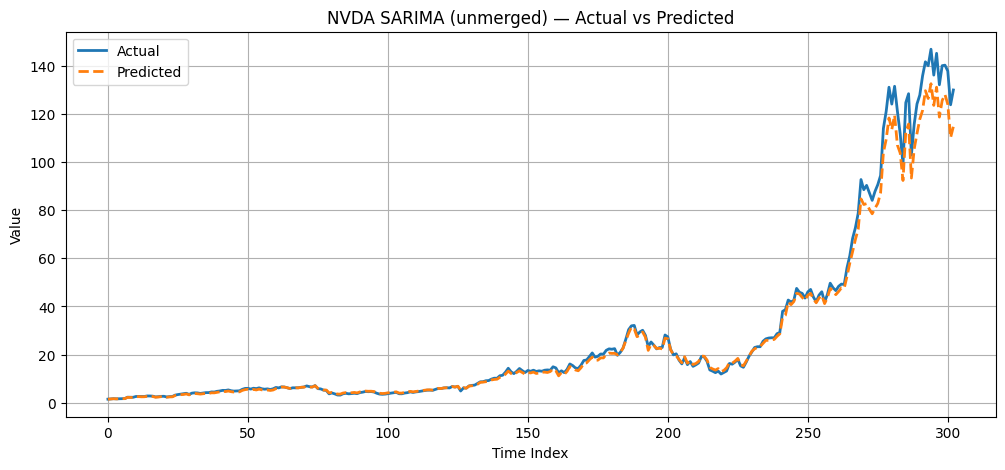

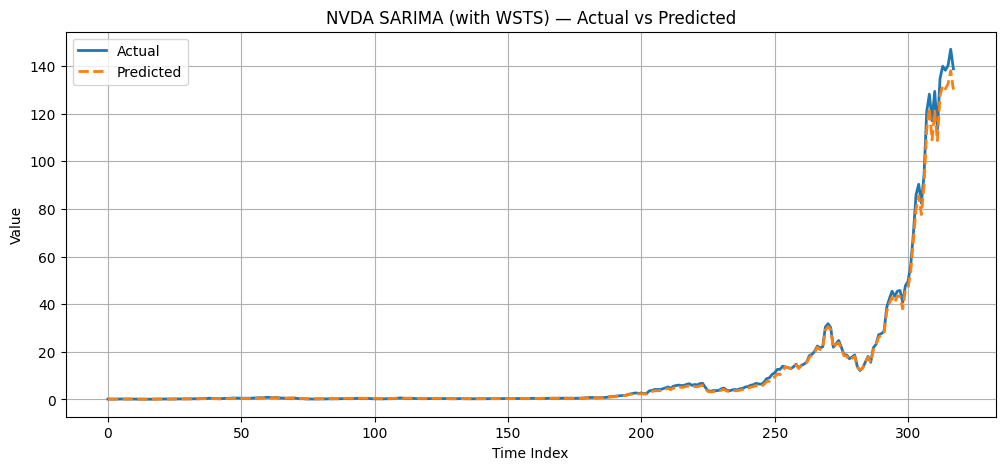

In [103]:
print_cv_summary(results_nvda_sarima_unmerged, name="NVDA SARIMA (unmerged)")
print_cv_summary(results_nvda_sarima, name="NVDA SARIMA (with WSTS)")

plot_actual_vs_predicted(results_nvda_sarima_unmerged, title="NVDA SARIMA (unmerged) — Actual vs Predicted")
plot_actual_vs_predicted(results_nvda_sarima, title="NVDA SARIMA (with WSTS) — Actual vs Predicted")

#### 5.1.2 Sarima - Exxon

In [99]:
# Exxon unmerged dataset (baseline OHLCV only)
results_exxon_sarima_unmerged = train_sarima_ts(
    data_raw=exxon_table,                     # baseline Exxon stock data
    features=["open", "high", "low", "close", "volume"],  # basic stock features
    target_col="close",                       # target is closing price
    order=(1, 1, 1),                          # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0),              # no seasonality for daily stock data
    n_splits=5                                # CV folds
)


  Fold 1: MAE=$0.8968  RMSE=$1.0148  R²=0.9167
  Fold 2: MAE=$0.7715  RMSE=$0.9146  R²=0.9579
  Fold 3: MAE=$3.4423  RMSE=$3.9853  R²=0.8898
  Fold 4: MAE=$2.4170  RMSE=$3.1402  R²=0.9662
  Fold 5: MAE=$1.0070  RMSE=$1.1970  R²=0.9587


In [ ]:
# Exxon (merged with WTI oil features)
results_exxon_sarima = train_sarima_ts(
    data_raw=merged_exxon_df,                # engineered Exxon DataFrame
    features=list(merged_exxon_df.columns),  # all feature names
    target_col="close",                      # target column
    order=(1, 1, 1),                         # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0),             # no seasonality for daily stock data
    n_splits=5                               # CV folds
)


  Fold 1: MAE=$1.1436  RMSE=$1.3196  R²=0.8659
  Fold 2: MAE=$0.6396  RMSE=$0.7601  R²=0.9712
  Fold 3: MAE=$3.5483  RMSE=$4.0546  R²=0.8886
  Fold 4: MAE=$2.6641  RMSE=$3.5219  R²=0.9591
  Fold 5: MAE=$1.1201  RMSE=$1.4320  R²=0.9418



===== Exxon SARIMA (with WTI) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.8968  1.0148  0.9167
2     0.7715  0.9146  0.9579
3     3.4423  3.9853  0.8898
4     2.4170  3.1402  0.9662
5     1.0070  1.1970  0.9587

Means:
MAE  : 1.7069
RMSE : 2.0504
R2   : 0.9379

Std:
MAE  : 1.1765
RMSE : 1.4162
R2   : 0.0332

===== Exxon SARIMA (unmerged) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.8968  1.0148  0.9167
2     0.7715  0.9146  0.9579
3     3.4423  3.9853  0.8898
4     2.4170  3.1402  0.9662
5     1.0070  1.1970  0.9587

Means:
MAE  : 1.7069
RMSE : 2.0504
R2   : 0.9379

Std:
MAE  : 1.1765
RMSE : 1.4162
R2   : 0.0332


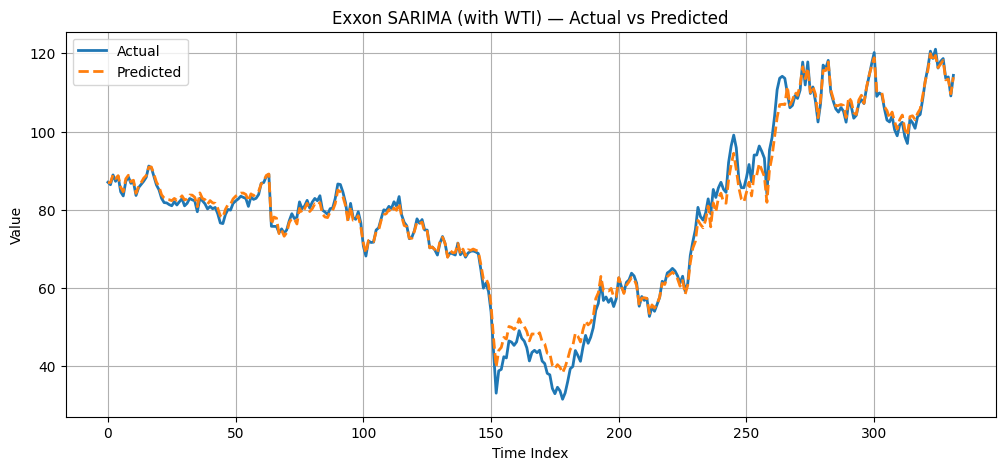

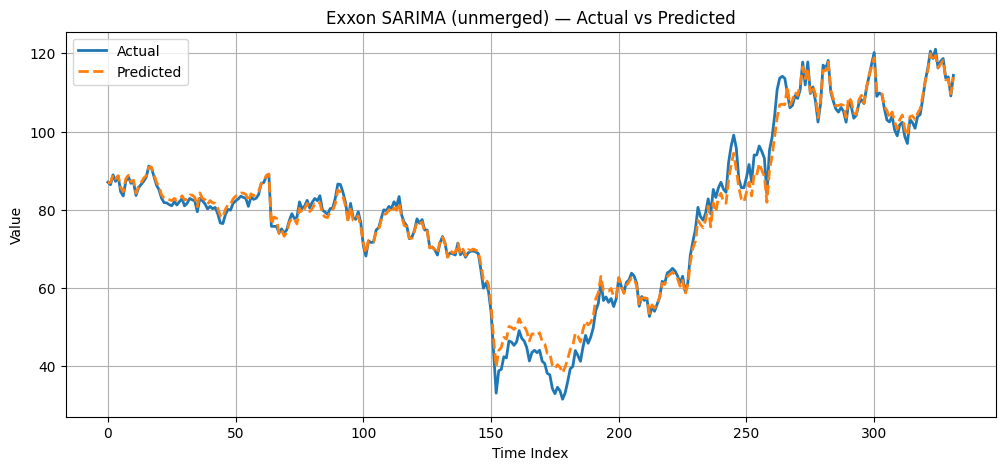

In [100]:
print_cv_summary(results_exxon_sarima, name="Exxon SARIMA (with WTI)")
print_cv_summary(results_exxon_sarima_unmerged, name="Exxon SARIMA (unmerged)")

plot_actual_vs_predicted(results_exxon_sarima, title="Exxon SARIMA (with WTI) — Actual vs Predicted")
plot_actual_vs_predicted(results_exxon_sarima_unmerged, title="Exxon SARIMA (unmerged) — Actual vs Predicted")  


#### 5.1.3 Sarima - Toyota

In [101]:
# Toyota unmerged dataset (baseline OHLCV + adj_close)
results_toyota_sarima_unmerged = train_sarima_ts(
    data_raw=toyota_table,                     # baseline Toyota stock data
    features=["open", "high", "low", "close", "adj_close", "volume"],  # basic features
    target_col="adj_close",                    # target is adjusted close
    order=(1, 1, 1),                           # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0),               # no seasonality for daily stock data
    n_splits=5                                 # CV folds
)


  Fold 1: MAE=$2.4035  RMSE=$3.1803  R²=0.8861
  Fold 2: MAE=$1.7519  RMSE=$2.2218  R²=0.9217
  Fold 3: MAE=$4.9659  RMSE=$6.3284  R²=0.9139
  Fold 4: MAE=$1.6313  RMSE=$2.5666  R²=0.9767
  Fold 5: MAE=$5.3665  RMSE=$5.8242  R²=0.9192


In [ ]:
# Toyota (merged with USD/JPY — FX features included)
results_toyota_sarima = train_sarima_ts(
    data_raw=merged_toyota_df,                # engineered Toyota DataFrame
    features=list(merged_toyota_df.columns),  # all feature names
    target_col="close",                       # target column
    order=(1, 1, 1),                          # ARIMA(p,d,q)
    seasonal_order=(0, 0, 0, 0),              # no seasonality for daily stock data
    n_splits=5                                # CV folds
)


  [Fold 1] Skipped — numerical blowup detected.
  Fold 2: MAE=$1.8451  RMSE=$2.3213  R²=0.9283
  Fold 3: MAE=$5.4205  RMSE=$6.7747  R²=0.9023
  Fold 4: MAE=$1.7864  RMSE=$2.8521  R²=0.9767
  Fold 5: MAE=$3.7625  RMSE=$4.3064  R²=0.9605



===== Toyota SARIMA (unmerged) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     2.4035  3.1803  0.8861
2     1.7519  2.2218  0.9217
3     4.9659  6.3284  0.9139
4     1.6313  2.5666  0.9767
5     5.3665  5.8242  0.9192

Means:
MAE  : 3.2238
RMSE : 4.0243
R2   : 0.9235

Std:
MAE  : 1.8029
RMSE : 1.9128
R2   : 0.0330

===== Toyota SARIMA (with USD/JPY) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     2.4035  3.1803  0.8861
2     1.7519  2.2218  0.9217
3     4.9659  6.3284  0.9139
4     1.6313  2.5666  0.9767
5     5.3665  5.8242  0.9192

Means:
MAE  : 3.2238
RMSE : 4.0243
R2   : 0.9235

Std:
MAE  : 1.8029
RMSE : 1.9128
R2   : 0.0330


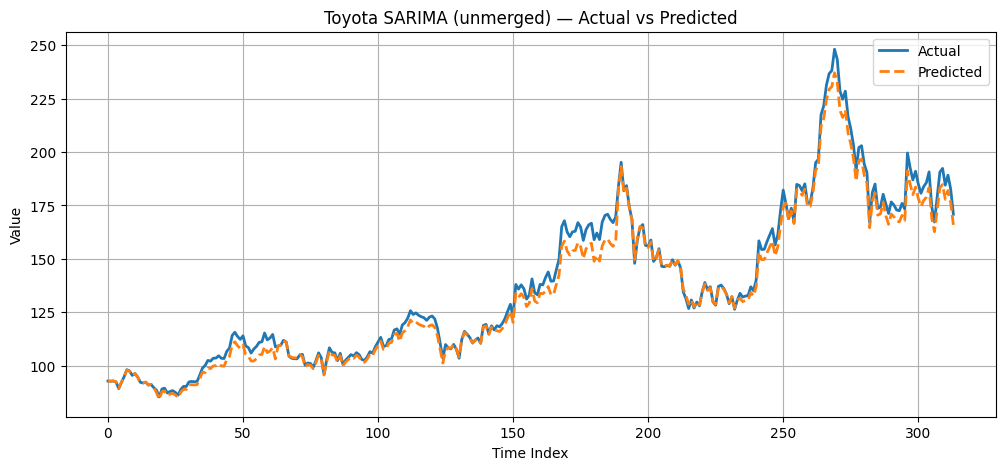

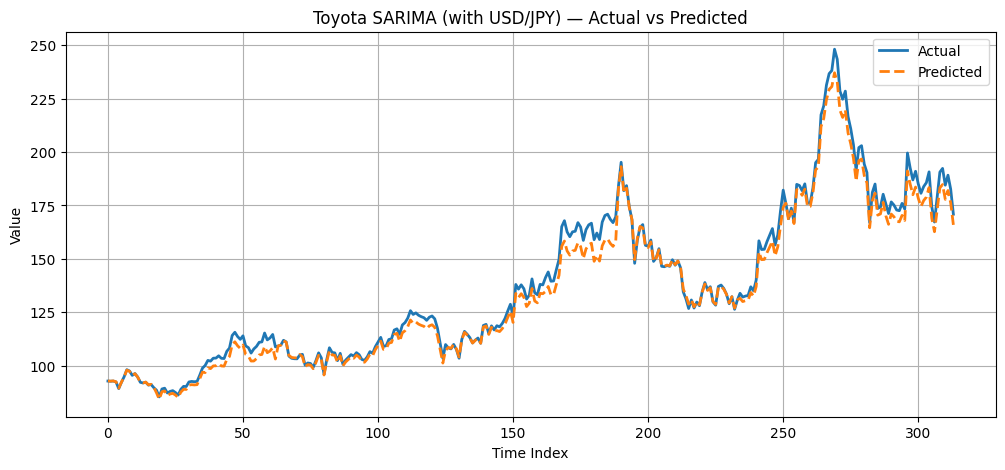

In [102]:
print_cv_summary(results_toyota_sarima_unmerged, name="Toyota SARIMA (unmerged)")
print_cv_summary(results_toyota_sarima, name="Toyota SARIMA (with USD/JPY)")

plot_actual_vs_predicted(results_toyota_sarima_unmerged, title="Toyota SARIMA (unmerged) — Actual vs Predicted")
plot_actual_vs_predicted(results_toyota_sarima, title="Toyota SARIMA (with USD/JPY) — Actual vs Predicted")


### 5.2 SVR

#### 5.2.1 SVR - NVIDIA

Fold 1: MAE=$0.0072  RMSE=$0.0112  R²=0.9966
Fold 2: MAE=$0.0108  RMSE=$0.0161  R²=0.9894
Fold 3: MAE=$0.0066  RMSE=$0.0107  R²=0.9963
Fold 4: MAE=$0.1087  RMSE=$0.1705  R²=0.9954
Fold 5: MAE=$1.2231  RMSE=$2.1966  R²=0.9972

===== SVR (LINEAR) — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     0.0072  0.0112  0.9966
2     0.0108  0.0161  0.9894
3     0.0066  0.0107  0.9963
4     0.1087  0.1705  0.9954
5     1.2231  2.1966  0.9972

Mean: {'MAE': 0.2713, 'RMSE': 0.481, 'R²': 0.995}
Std:  {'MAE': 0.5339, 'RMSE': 0.9615, 'R²': 0.0032}


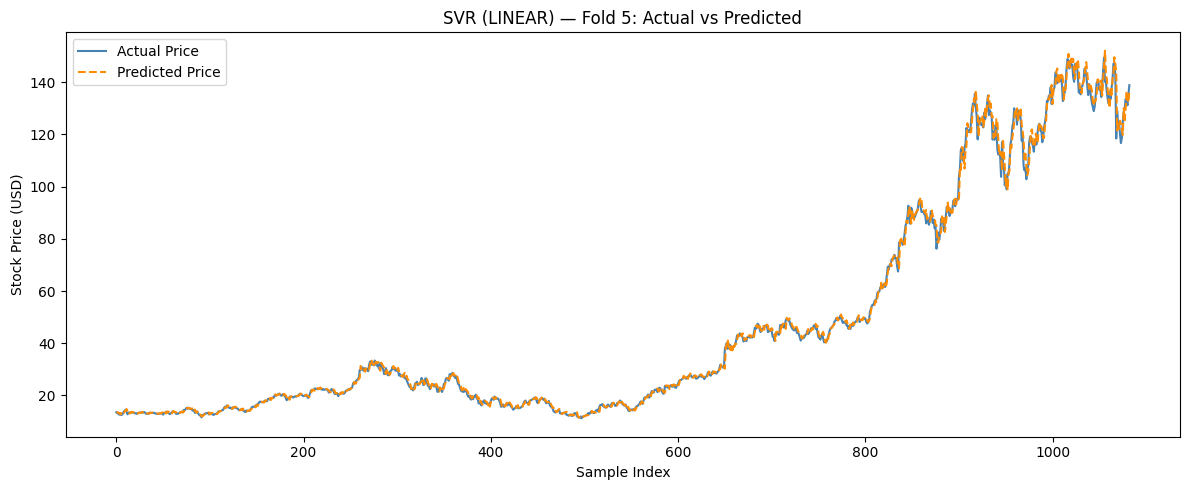

In [ ]:
# NVDA unmerged dataset
svr_nvda_results_unmerged = train_svr_ts(
    data_raw=nvda_data,               # baseline NVDA stock data
    n_splits=5,
    window_size=10,
    target_index=nvda_target_idx,     # index of "close" in baseline features
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    kernel='linear'
)


Fold 1: MAE=$0.0961  RMSE=$0.1318  R²=0.9901
Fold 2: MAE=$0.1340  RMSE=$0.2011  R²=0.9654
Fold 3: MAE=$0.3482  RMSE=$0.4946  R²=0.9907
Fold 4: MAE=$0.6811  RMSE=$0.9204  R²=0.9847
Fold 5: MAE=$2.4098  RMSE=$3.5317  R²=0.9909

===== SVR (LINEAR) — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     0.0961  0.1318  0.9901
2     0.1340  0.2011  0.9654
3     0.3482  0.4946  0.9907
4     0.6811  0.9204  0.9847
5     2.4098  3.5317  0.9909

Mean: {'MAE': 0.7339, 'RMSE': 1.0559, 'R²': 0.9844}
Std:  {'MAE': 0.9653, 'RMSE': 1.4184, 'R²': 0.0109}


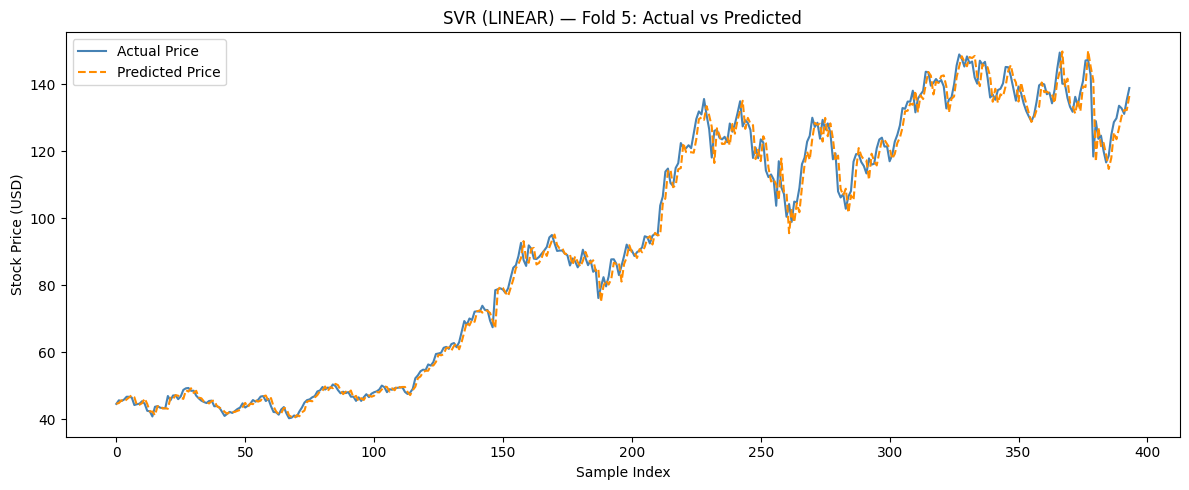

In [106]:
# NVDA with Auxiliary Data (WSTS)
svr_nvda_results_aux = train_svr_ts(
    data_raw=merged_nvda_df.values,        # engineered NVDA DataFrame
    n_splits=5,
    window_size=10,
    target_index=features_nvda.index("close"),  # or nvda_target_idx
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    kernel='linear',                      
    plot_last_fold=True
)


#### 5.2.2 SVR - Exxon

Fold 1: MAE=$0.6296  RMSE=$0.8780  R²=0.9368
Fold 2: MAE=$0.7650  RMSE=$0.9865  R²=0.9517
Fold 3: MAE=$1.1009  RMSE=$1.4037  R²=0.9859
Fold 4: MAE=$1.3051  RMSE=$1.7292  R²=0.9897
Fold 5: MAE=$1.2490  RMSE=$1.6198  R²=0.9256

===== SVR (LINEAR) — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     0.6296  0.8780  0.9368
2     0.7650  0.9865  0.9517
3     1.1009  1.4037  0.9859
4     1.3051  1.7292  0.9897
5     1.2490  1.6198  0.9256

Mean: {'MAE': 1.0099, 'RMSE': 1.3234, 'R²': 0.958}
Std:  {'MAE': 0.2988, 'RMSE': 0.3778, 'R²': 0.0288}


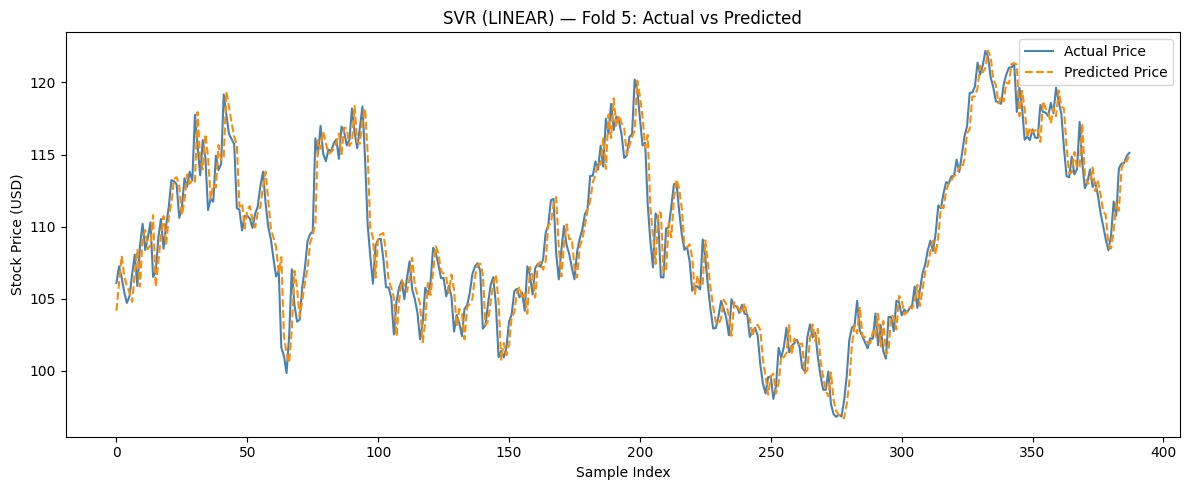

In [110]:
# Exxon unmerged dataset (baseline OHLCV only) — Linear kernel
svr_exxon_results_unmerged = train_svr_ts(
    data_raw=exxon_table.values,     # <-- use .values here
    n_splits=5,
    window_size=10,
    target_index=exxon_target_idx,   # index of "close" in baseline features
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    kernel='linear',                 # linear kernel for consistency
    plot_last_fold=True
)


Fold 1: MAE=$0.7016  RMSE=$0.9518  R²=0.9291
Fold 2: MAE=$0.8052  RMSE=$1.0365  R²=0.9471
Fold 3: MAE=$1.1590  RMSE=$1.5535  R²=0.9832
Fold 4: MAE=$1.3096  RMSE=$1.7529  R²=0.9898
Fold 5: MAE=$1.2454  RMSE=$1.6283  R²=0.9258

===== SVR (LINEAR) — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     0.7016  0.9518  0.9291
2     0.8052  1.0365  0.9471
3     1.1590  1.5535  0.9832
4     1.3096  1.7529  0.9898
5     1.2454  1.6283  0.9258

Mean: {'MAE': 1.0442, 'RMSE': 1.3846, 'R²': 0.955}
Std:  {'MAE': 0.2732, 'RMSE': 0.3647, 'R²': 0.03}


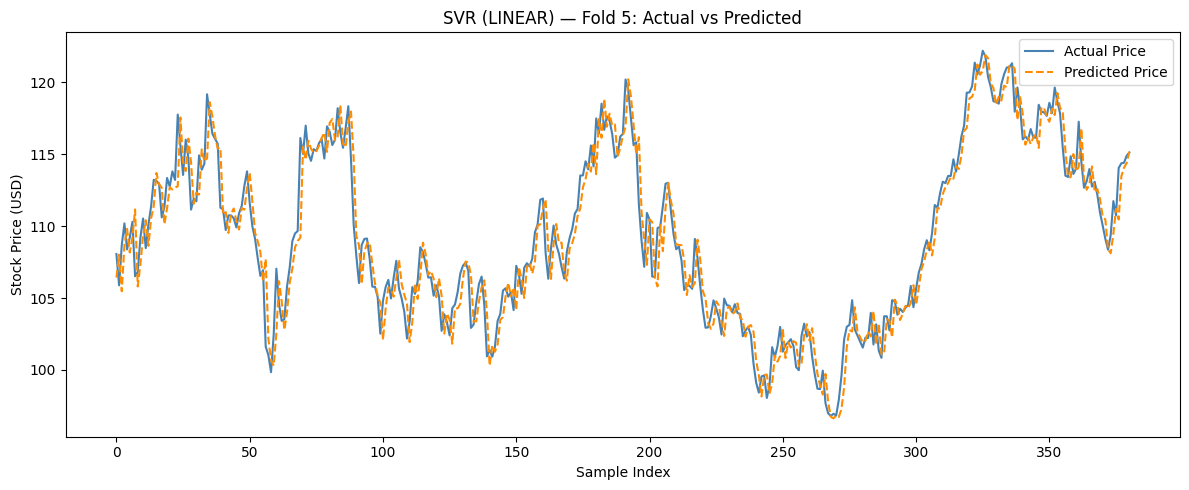

In [112]:
# Exxon with Auxiliary Data (WTI oil features) — Linear kernel
svr_exxon_results_aux = train_svr_ts(
    data_raw=merged_exxon_df.values,        # engineered Exxon DataFrame
    n_splits=5,
    window_size=10,
    target_index=exxon_target_idx,          # index of "close"
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    kernel='linear',                        
    plot_last_fold=True
)


#### 5.2.3 SVR - Toyota

Fold 1: MAE=$1.4079  RMSE=$1.8308  R²=0.9634
Fold 2: MAE=$0.9857  RMSE=$1.5039  R²=0.9653
Fold 3: MAE=$1.5206  RMSE=$2.0248  R²=0.9909
Fold 4: MAE=$2.0948  RMSE=$2.6980  R²=0.9710
Fold 5: MAE=$2.5753  RMSE=$3.4835  R²=0.9712

===== SVR (LINEAR) — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     1.4079  1.8308  0.9634
2     0.9857  1.5039  0.9653
3     1.5206  2.0248  0.9909
4     2.0948  2.6980  0.9710
5     2.5753  3.4835  0.9712

Mean: {'MAE': 1.7168, 'RMSE': 2.3082, 'R²': 0.9724}
Std:  {'MAE': 0.6222, 'RMSE': 0.7887, 'R²': 0.0109}


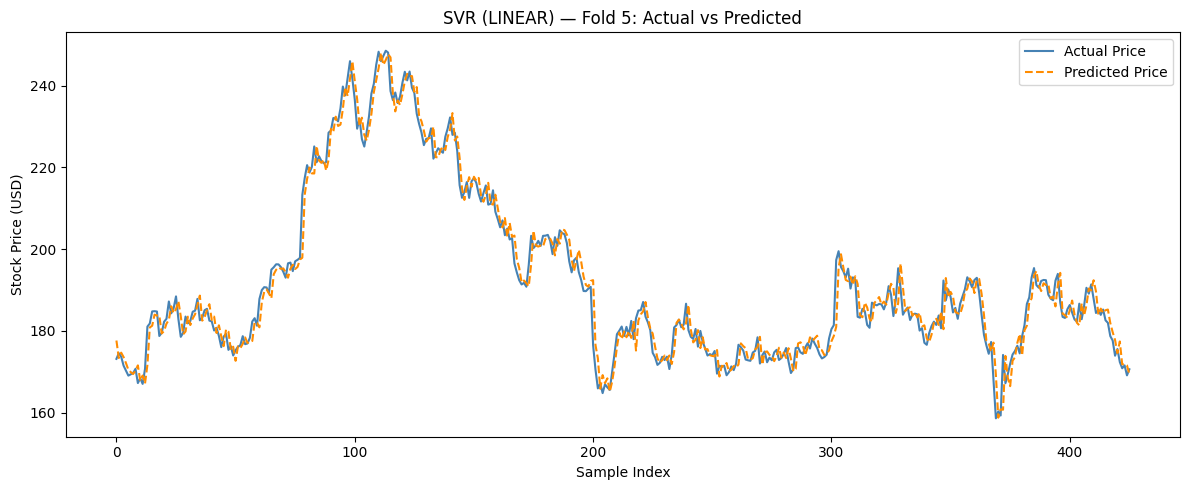

In [113]:
# Toyota unmerged dataset — Linear kernel
svr_toyota_results_unmerged = train_svr_ts(
    data_raw=toyota_df.values,          # baseline Toyota stock data
    n_splits=5,
    window_size=10,
    target_index=toyota_target_idx,     # index of "close" in baseline features
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    kernel='linear',                   
    plot_last_fold=True
)


Fold 1: MAE=$1.4079  RMSE=$1.8308  R²=0.9634
Fold 2: MAE=$0.9857  RMSE=$1.5039  R²=0.9653
Fold 3: MAE=$1.5206  RMSE=$2.0248  R²=0.9909
Fold 4: MAE=$2.0948  RMSE=$2.6980  R²=0.9710
Fold 5: MAE=$2.5753  RMSE=$3.4835  R²=0.9712

===== SVR (LINEAR) — TimeSeriesSplit CV Summary =====
         MAE    RMSE      R²
fold                        
1     1.4079  1.8308  0.9634
2     0.9857  1.5039  0.9653
3     1.5206  2.0248  0.9909
4     2.0948  2.6980  0.9710
5     2.5753  3.4835  0.9712

Mean: {'MAE': 1.7168, 'RMSE': 2.3082, 'R²': 0.9724}
Std:  {'MAE': 0.6222, 'RMSE': 0.7887, 'R²': 0.0109}


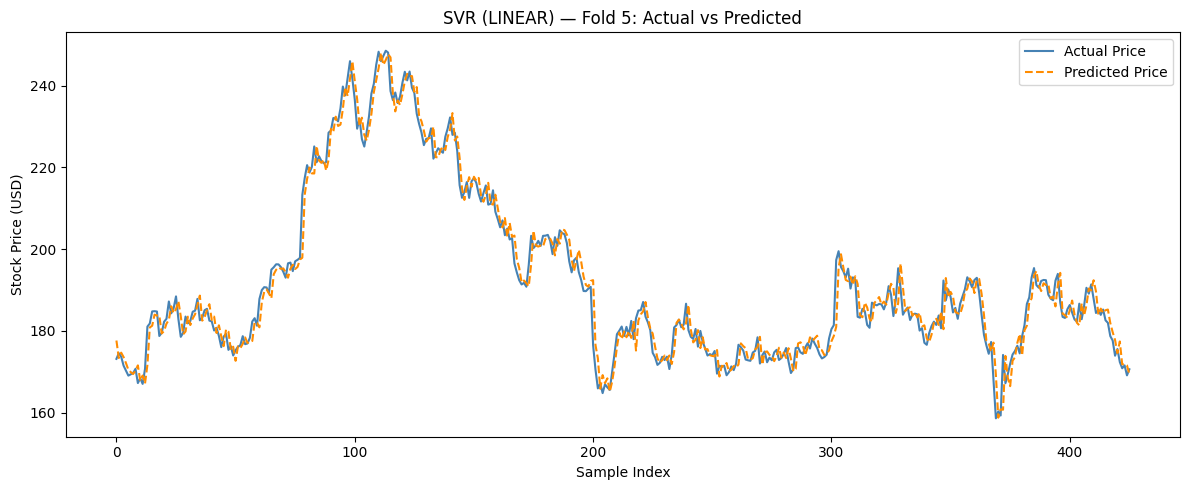

In [114]:
# Toyota with Auxiliary Data — Linear kernel
svr_toyota_results_aux = train_svr_ts(
    data_raw=merged_toyota_df.values,       # engineered Toyota DataFrame
    n_splits=5,
    window_size=10,
    target_index=toyota_target_idx,         # index of "close"
    make_windows=make_windows,
    inv_scale=inv_scale,
    C=100, gamma='scale', epsilon=0.01,
    kernel='linear',                      
    plot_last_fold=True
)


### 5.3 Linear Regression

#### 5.3.1 Linear Regression - NVIDIA


===== NVDA Unmerged (Baseline) Linear Regression CV SUMMARY =====
           MAE      RMSE            R2
fold                                  
1       0.0057    0.0084  9.980000e-01
2       0.0079    0.0126  9.932000e-01
3     277.6513  385.4338 -5.044864e+06
4       0.0054    0.0079  9.913000e-01
5       0.1555    0.2624  9.925000e-01

Means:
MAE  : 55.5652
RMSE : 77.1450
R2   : -1008972.0652

Std:
MAE  : 124.1500
RMSE : 172.3387
R2   : 2256132.3473


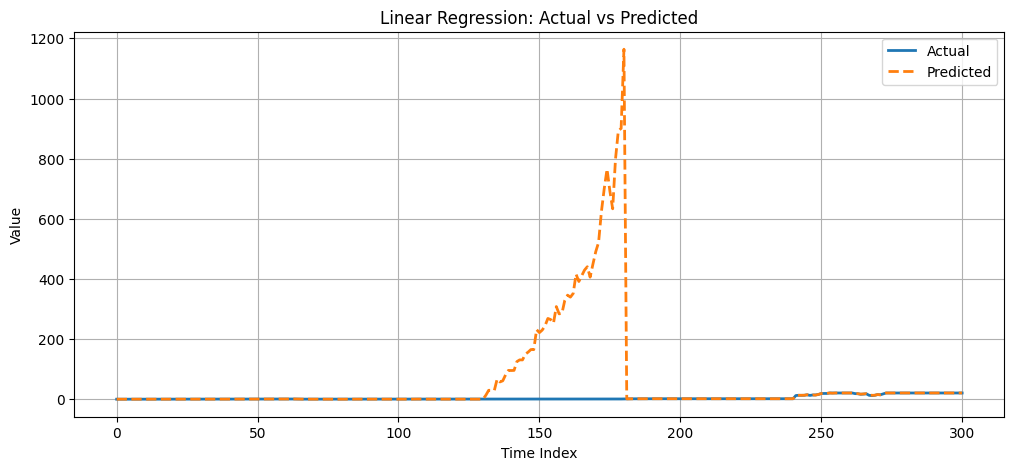

In [123]:
# NVDA unmerged dataset — Linear Regression
results_nvda_unmerged = train_linear_regression_ts(
    data_raw=nvda_df,                      # baseline NVDA stock data
    features=list(nvda_df.columns),        # feature list
    target_index=nvda_target_idx,          # index of "close"
    window_size=10,
    n_splits=5
)

# Print results
print_cv_summary(results_nvda_unmerged, name="NVDA Unmerged (Baseline) Linear Regression")

# Plot predictions
plot_actual_vs_predicted(
    results_nvda_unmerged,
    title="Linear Regression: Actual vs Predicted"
)



===== NVDA Merged Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.2077  0.2297  0.8303
2     0.1318  0.1956  0.9673
3     0.1022  0.1386  0.9751
4     0.6677  0.9129  0.9850
5     0.7786  0.8846  0.9904

Means:
MAE  : 0.3776
RMSE : 0.4723
R2   : 0.9496

Std:
MAE  : 0.3202
RMSE : 0.3908
R2   : 0.0673


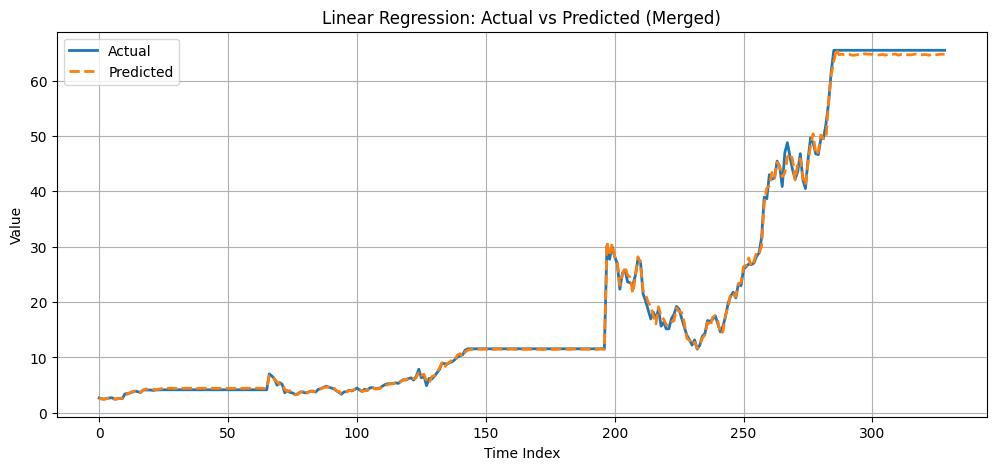

In [124]:
# NVDA merged dataset (with WSTS auxiliary features) — Linear Regression
results_nvda_merged = train_linear_regression_ts(
    data_raw=merged_nvda_df,                # engineered NVDA DataFrame
    features=list(merged_nvda_df.columns),  # include all engineered features
    target_index=nvda_target_idx,           # index of "close"
    window_size=10,
    n_splits=5
)

# Print results
print_cv_summary(results_nvda_merged, name="NVDA Merged Linear Regression")

# Plot predictions
plot_actual_vs_predicted(
    results_nvda_merged,
    title="Linear Regression: Actual vs Predicted (Merged)"
)


#### 5.3.2 Linear Regression - Exxon


===== Exxon Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.7170  1.0028  0.9176
2     0.8023  1.0302  0.9474
3     0.8726  1.0648  0.9780
4     1.4490  1.9086  0.9875
5     1.2762  1.6373  0.9240

Means:
MAE  : 1.0234
RMSE : 1.3287
R2   : 0.9509

Std:
MAE  : 0.3204
RMSE : 0.4173
R2   : 0.0313


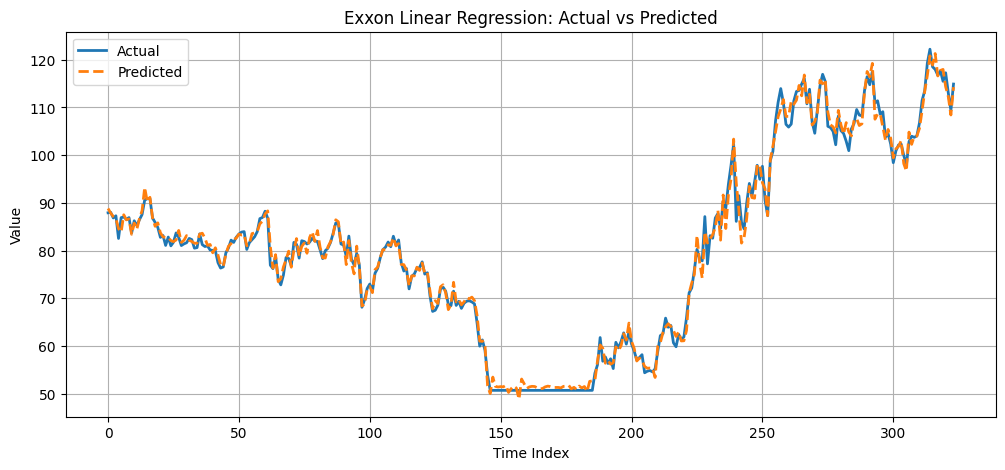

In [128]:
# Exxon unmerged dataset — Linear Regression
results_exxon_unmerged = train_linear_regression_ts(
    data_raw=exxon_df,
    features=list(exxon_df.columns),
    target_index=exxon_target_idx,
    window_size=10,
    n_splits=5
)

# Print results
print_cv_summary(results_exxon_unmerged, name="Exxon Linear Regression")

# Plot predictions
plot_actual_vs_predicted(
    results_exxon_unmerged,
    title="Exxon Linear Regression: Actual vs Predicted"
)



===== Exxon Merged Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.7068  0.9420  0.9306
2     0.8350  1.0568  0.9450
3     1.1099  1.3660  0.9640
4     1.3651  1.8554  0.9886
5     1.2525  1.6252  0.9261

Means:
MAE  : 1.0538
RMSE : 1.3691
R2   : 0.9508

Std:
MAE  : 0.2774
RMSE : 0.3814
R2   : 0.0258


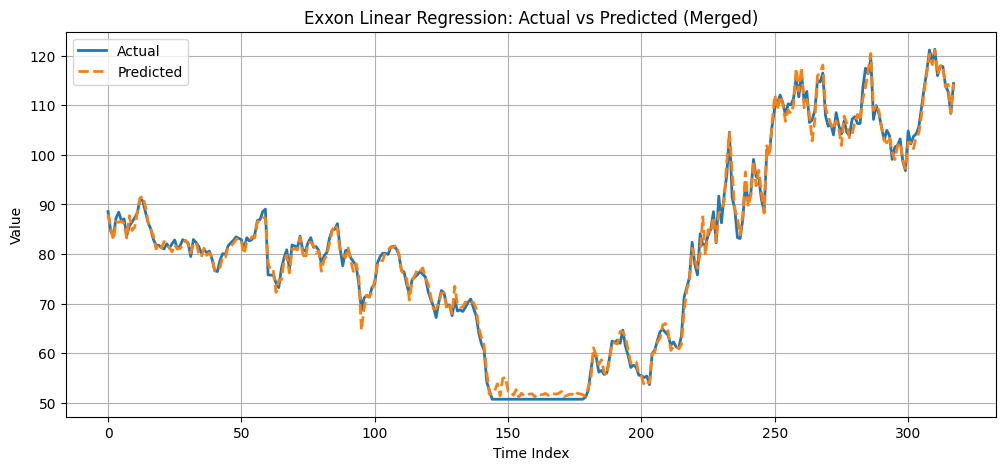

In [126]:
# Exxon merged dataset (with auxiliary features) — Linear Regression
results_exxon_merged = train_linear_regression_ts(
    data_raw=merged_exxon_df,               # engineered Exxon DataFrame
    features=list(merged_exxon_df.columns), # include all engineered features
    target_index=exxon_target_idx,          # index of "close"
    window_size=10,
    n_splits=5
)

# Print results
print_cv_summary(results_exxon_merged, name="Exxon Merged Linear Regression")

# Plot predictions
plot_actual_vs_predicted(
    results_exxon_merged,
    title="Exxon Linear Regression: Actual vs Predicted (Merged)"
)


#### 5.3.3 Linear Regression - Toyata


===== Toyota Unmerged (Baseline) Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     1.3719  1.7381  0.9671
2     0.9956  1.5335  0.9639
3     1.0637  1.4280  0.9914
4     2.3178  2.9235  0.9660
5     2.6072  3.5156  0.9706

Means:
MAE  : 1.6712
RMSE : 2.2277
R2   : 0.9718

Std:
MAE  : 0.7432
RMSE : 0.9360
R2   : 0.0112


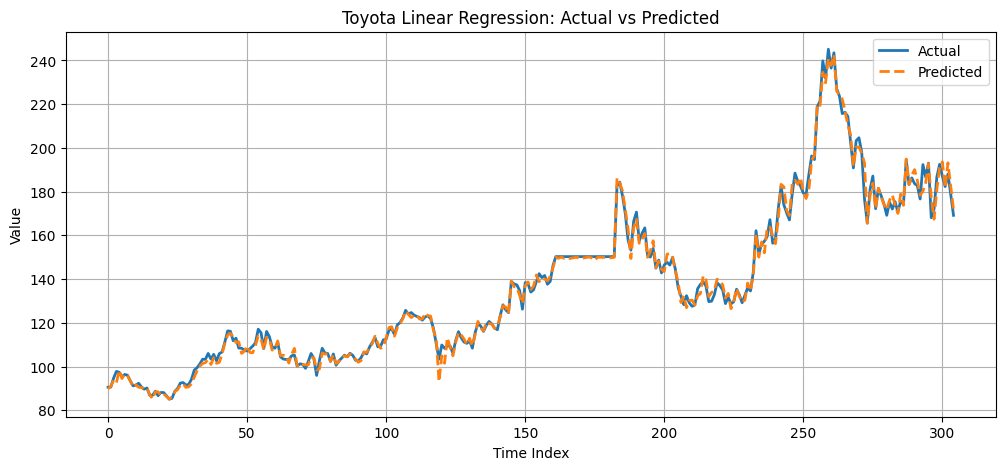

In [129]:
# Toyota unmerged dataset — Linear Regression
results_toyota_unmerged = train_linear_regression_ts(
    data_raw=toyota_df,                      # baseline Toyota stock data
    features=list(toyota_df.columns),        # feature list
    target_index=toyota_target_idx,          # index of "close" or "adj_close"
    window_size=10,
    n_splits=5
)

# Print results
print_cv_summary(results_toyota_unmerged, name="Toyota Unmerged (Baseline) Linear Regression")

# Plot predictions
plot_actual_vs_predicted(
    results_toyota_unmerged,
    title="Toyota Linear Regression: Actual vs Predicted"
)



===== Toyota Merged Linear Regression CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     1.3719  1.7381  0.9671
2     0.9956  1.5335  0.9639
3     1.0637  1.4280  0.9914
4     2.3178  2.9235  0.9660
5     2.6072  3.5156  0.9706

Means:
MAE  : 1.6712
RMSE : 2.2277
R2   : 0.9718

Std:
MAE  : 0.7432
RMSE : 0.9360
R2   : 0.0112


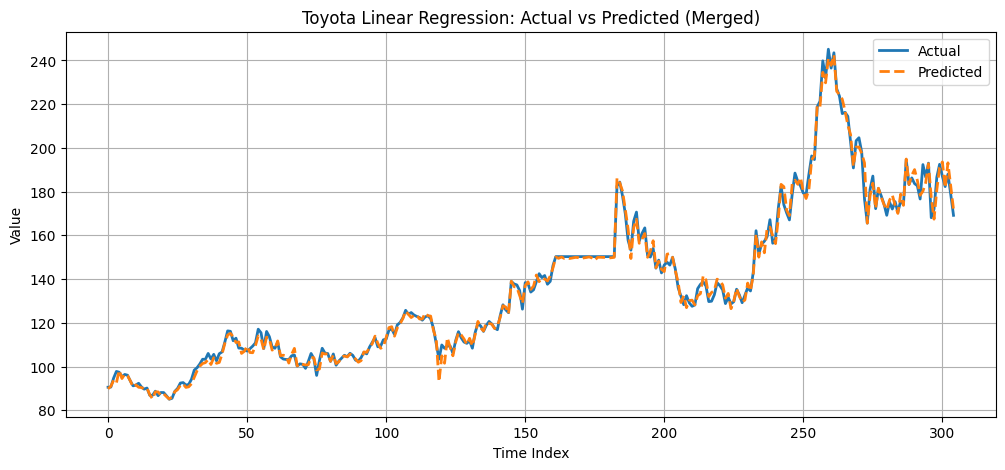

In [130]:
# Toyota merged dataset (with FX auxiliary features) — Linear Regression
results_toyota_merged = train_linear_regression_ts(
    data_raw=merged_toyota_df,               # engineered Toyota DataFrame
    features=list(merged_toyota_df.columns), # include all engineered features
    target_index=toyota_target_idx,          # index of "close"
    window_size=10,
    n_splits=5
)

# Print results
print_cv_summary(results_toyota_merged, name="Toyota Merged Linear Regression")

# Plot predictions
plot_actual_vs_predicted(
    results_toyota_merged,
    title="Toyota Linear Regression: Actual vs Predicted (Merged)"
)


### 5.4 Random Forest

#### 5.4.1 Random Forest - NVIDIA

  Fold 1: MAE=$0.0074  RMSE=$0.0111  R²=0.9968
  Fold 2: MAE=$0.0110  RMSE=$0.0163  R²=0.9885
  Fold 3: MAE=$0.0072  RMSE=$0.0119  R²=0.9955
  Fold 4: MAE=$0.1085  RMSE=$0.1718  R²=0.9953
  Fold 5: MAE=$1.2862  RMSE=$2.2800  R²=0.9970

===== NVDA Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.0074  0.0111  0.9968
2     0.0110  0.0163  0.9885
3     0.0072  0.0119  0.9955
4     0.1085  0.1718  0.9953
5     1.2862  2.2800  0.9970

Means:
MAE  : 0.2841
RMSE : 0.4982
R2   : 0.9946

Std:
MAE  : 0.5619
RMSE : 0.9984
R2   : 0.0035


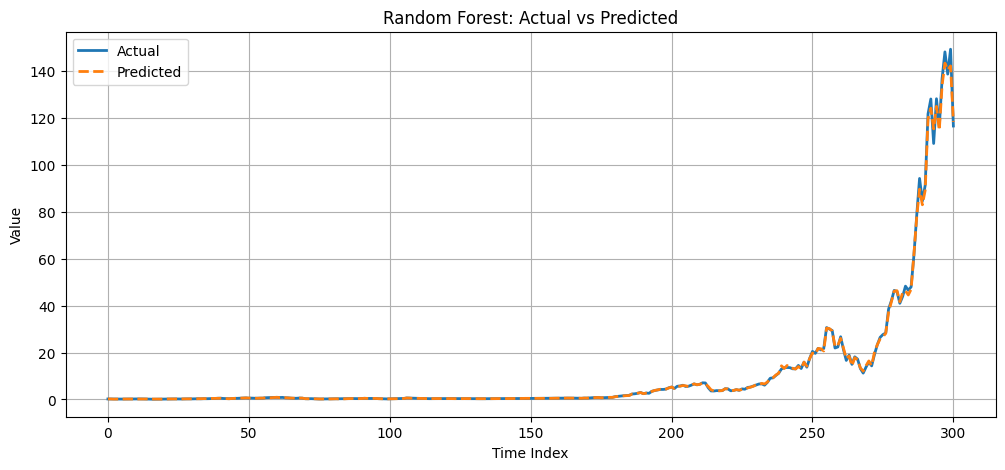

In [115]:
# NVDA unmerged dataset — Random Forest
results_nvda_rf = train_random_forest_ts(
    data_raw=nvda_df,                      # baseline NVDA stock data
    features=list(nvda_df.columns),        # feature list from DataFrame
    target_col="close",                    # target column
)

print_cv_summary(results_nvda_rf, name="NVDA Random Forest")

plot_actual_vs_predicted(
    results_nvda_rf,
    title="Random Forest: Actual vs Predicted"
)


  Fold 1: MAE=$0.0944  RMSE=$0.1253  R²=0.9910
  Fold 2: MAE=$0.1255  RMSE=$0.1901  R²=0.9691
  Fold 3: MAE=$0.5098  RMSE=$0.6700  R²=0.9829
  Fold 4: MAE=$0.6603  RMSE=$0.9111  R²=0.9850
  Fold 5: MAE=$2.3062  RMSE=$3.3779  R²=0.9917

===== NVDA Random Forest (Merged) CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.0944  0.1253  0.9910
2     0.1255  0.1901  0.9691
3     0.5098  0.6700  0.9829
4     0.6603  0.9111  0.9850
5     2.3062  3.3779  0.9917

Means:
MAE  : 0.7392
RMSE : 1.0549
R2   : 0.9840

Std:
MAE  : 0.9092
RMSE : 1.3395
R2   : 0.0091


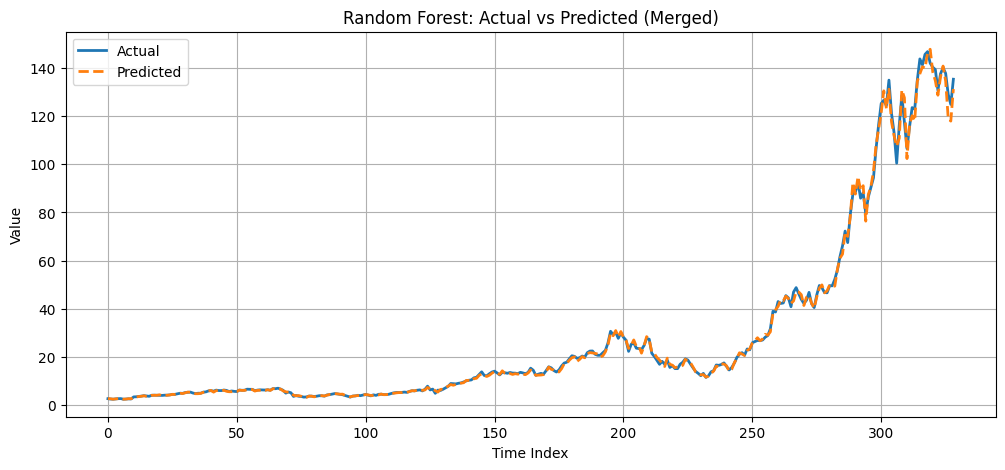

In [116]:
# NVDA with WSTS Auxiliary Data — Random Forest
results_nvda_merged_rf = train_random_forest_ts(
    data_raw=merged_nvda_df,                # engineered NVDA DataFrame with WSTS features
    features=list(merged_nvda_df.columns),  # include all engineered features
    target_col="close",                     # target column
)

print_cv_summary(results_nvda_merged_rf, name="NVDA Random Forest (Merged)")

plot_actual_vs_predicted(
    results_nvda_merged_rf,
    title="Random Forest: Actual vs Predicted (Merged)"
)


#### 5.4.2 Random Forest - Exxon

  Fold 1: MAE=$0.6002  RMSE=$0.8365  R²=0.9441
  Fold 2: MAE=$0.7736  RMSE=$0.9900  R²=0.9529
  Fold 3: MAE=$1.0424  RMSE=$1.3734  R²=0.9863
  Fold 4: MAE=$1.4554  RMSE=$1.8831  R²=0.9879
  Fold 5: MAE=$1.3970  RMSE=$1.7871  R²=0.9096

===== Exxon Merged Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.6002  0.8365  0.9441
2     0.7736  0.9900  0.9529
3     1.0424  1.3734  0.9863
4     1.4554  1.8831  0.9879
5     1.3970  1.7871  0.9096

Means:
MAE  : 1.0537
RMSE : 1.3740
R2   : 0.9562

Std:
MAE  : 0.3753
RMSE : 0.4654
R2   : 0.0325


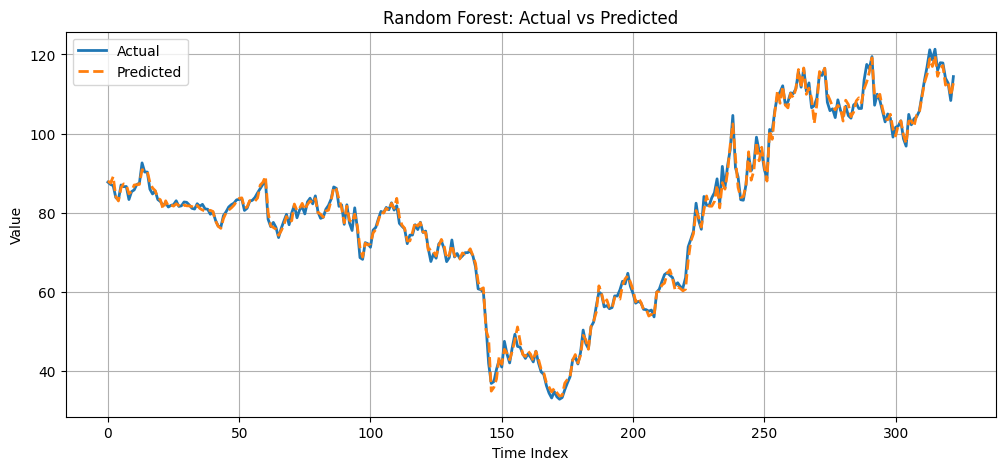

In [117]:
# Exxon
results_exxon_rf = train_random_forest_ts(
    data_raw=exxon_df,
    features=list(exxon_df.columns),
    target_col="close"
)
print_cv_summary(results_exxon_rf, name="Exxon Merged Random Forest")

plot_actual_vs_predicted(
    results_exxon_rf,
    title="Random Forest: Actual vs Predicted"
)

  Fold 1: MAE=$0.6007  RMSE=$0.8225  R²=0.9471
  Fold 2: MAE=$1.2747  RMSE=$1.6186  R²=0.8710
  Fold 3: MAE=$1.0093  RMSE=$1.3259  R²=0.9877
  Fold 4: MAE=$1.4608  RMSE=$1.9005  R²=0.9880
  Fold 5: MAE=$1.3345  RMSE=$1.7327  R²=0.9159

===== Exxon Merged Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.6007  0.8225  0.9471
2     1.2747  1.6186  0.8710
3     1.0093  1.3259  0.9877
4     1.4608  1.9005  0.9880
5     1.3345  1.7327  0.9159

Means:
MAE  : 1.1360
RMSE : 1.4800
R2   : 0.9419

Std:
MAE  : 0.3416
RMSE : 0.4231
R2   : 0.0499


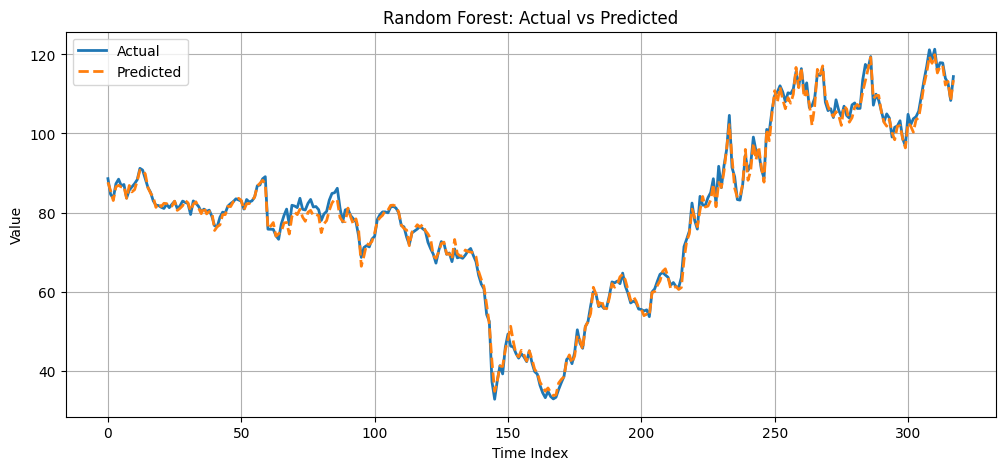

In [118]:
# Exxon (merged with WTI oil)
results_exxon_merged_rf = train_random_forest_ts(
    data_raw=merged_exxon_df,
    features=list(merged_exxon_df.columns),
    target_col="close"
)
print_cv_summary(results_exxon_merged_rf, name="Exxon Merged Random Forest")

plot_actual_vs_predicted(
    results_exxon_merged_rf,
    title="Random Forest: Actual vs Predicted"
)

#### 5.4.3 Random Forest - Toyota

  Fold 1: MAE=$0.9138  RMSE=$1.2530  R²=0.9846
  Fold 2: MAE=$1.2418  RMSE=$1.7868  R²=0.9582
  Fold 3: MAE=$1.7396  RMSE=$2.3318  R²=0.9883
  Fold 4: MAE=$2.4253  RMSE=$3.0513  R²=0.9686
  Fold 5: MAE=$2.5875  RMSE=$3.4790  R²=0.9744

===== Toyota Merged Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.9138  1.2530  0.9846
2     1.2418  1.7868  0.9582
3     1.7396  2.3318  0.9883
4     2.4253  3.0513  0.9686
5     2.5875  3.4790  0.9744

Means:
MAE  : 1.7816
RMSE : 2.3804
R2   : 0.9748

Std:
MAE  : 0.7263
RMSE : 0.9059
R2   : 0.0122


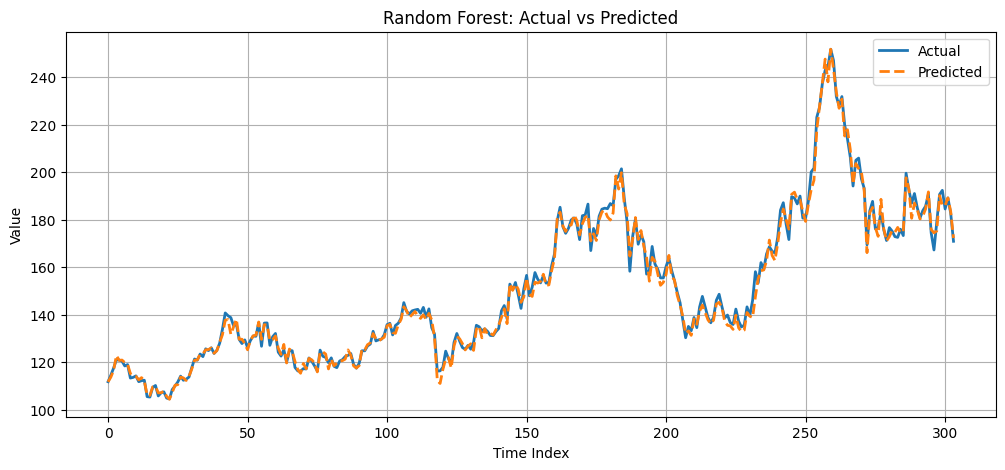

In [119]:
# Toyota
results_toyota_rf = train_random_forest_ts(
    data_raw=toyota_df,
    features=list(toyota_df.columns),
    target_col="close",
)
print_cv_summary(results_toyota_rf, name="Toyota Merged Random Forest")

plot_actual_vs_predicted(
    results_toyota_rf,
    title="Random Forest: Actual vs Predicted"
)

  Fold 1: MAE=$0.9138  RMSE=$1.2530  R²=0.9846
  Fold 2: MAE=$1.2418  RMSE=$1.7868  R²=0.9582
  Fold 3: MAE=$1.7396  RMSE=$2.3318  R²=0.9883
  Fold 4: MAE=$2.4253  RMSE=$3.0513  R²=0.9686
  Fold 5: MAE=$2.5875  RMSE=$3.4790  R²=0.9744

===== Toyota Merged Random Forest CV SUMMARY =====
         MAE    RMSE      R2
fold                        
1     0.9138  1.2530  0.9846
2     1.2418  1.7868  0.9582
3     1.7396  2.3318  0.9883
4     2.4253  3.0513  0.9686
5     2.5875  3.4790  0.9744

Means:
MAE  : 1.7816
RMSE : 2.3804
R2   : 0.9748

Std:
MAE  : 0.7263
RMSE : 0.9059
R2   : 0.0122


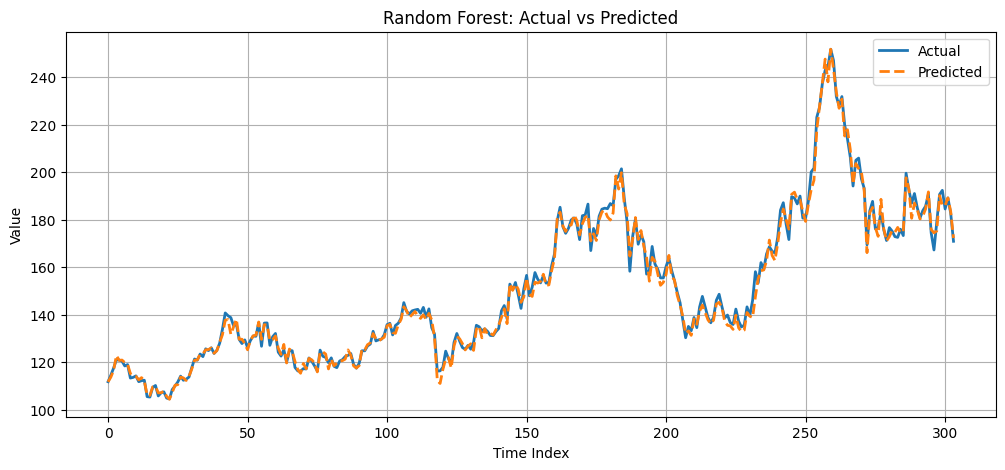

In [120]:
# Toyota (merged with USD/JPY)
results_toyota_merged_rf = train_random_forest_ts(
    data_raw=merged_toyota_df,
    features=list(merged_toyota_df.columns),
    target_col="close",
)
print_cv_summary(results_toyota_merged_rf, name="Toyota Merged Random Forest")

plot_actual_vs_predicted(
    results_toyota_merged_rf,
    title="Random Forest: Actual vs Predicted"
)

## Part 6: Feature Importance Analysis
The four models are split into two groups based on how importance is extracted.

### Group 1: SVR, Linear Regression, Random Forest
These three models utilize the same sliding-window sklearn interface, so one function handles all of them. The model and test split from the last cross-validation fold is used. 

__SVR RBF Note:__ Given that it had negative R² on folds 4–5, its permutation importance scores on a held-out test set drawn from that later period will be noisy and possibly misleading. It's still worth running, but it should be interpreted as "what the model thought mattered" rather than "what actually matters for prediction."

In [64]:
# Unified importance function
# Branches on model type to choose the best method
# Falls back on permutation importance when no native method exists

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def analyze_feature_importance(model, X_te, y_te, feature_names, window_size, title="Feature Importance",
                               color="steelblue"):
    
    n_features = len(feature_names)

    def aggregate(raw):
        # Sum importance across time steps
        matrix = np.array(raw).reshape(window_size, n_features)
        agg = matrix.sum(axis=0)
        return agg/agg.sum() # normalize to sum to 1
    
    def get_permutation_scores():
        result = permutation_importance(model, X_te, y_te, n_repeats=10, random_state=41, scoring="r2")
        return aggregate(result.importances_mean)
    
    # Branch by model type
    if isinstance(model, SVR):
        if model.kernel == "linear":
            # coef_ exists for linear kernel only
            scores = aggregate(np.abs(model.coef_[0]))
            method = "Coefficient |w|"
        else:
            # RBF and other kernels: no coef_, use permutation
            scores = get_permutation_scores()
            method = "Permutation (R² drop)"

    elif isinstance(model, LinearRegression):
        scores = aggregate(np.abs(model.coef_))
        method = "Coefficient |w|"

    elif isinstance(model, RandomForestRegressor):
        scores = aggregate(model.feature_importances_)
        method = "Built-in Impurity"

    else:
        # Fallback for any other sklearn-compatible model
        scores = get_permutation_scores()
        method = "Permutation (R² drop)"

    # Build results DataFrame
    df_imp = pd.DataFrame({"feature": feature_names, "importance": scores})
    df_imp = df_imp.sort_values("importance", ascending=False).reset_index(drop=True)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(df_imp["feature"], df_imp["importance"], color=color)
    plt.title(f"{title}\nMethod: {method}")
    plt.ylabel("Normalized Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(df_imp.to_string(index=False))
    return df_imp


#### Linear Regression Feature Importance

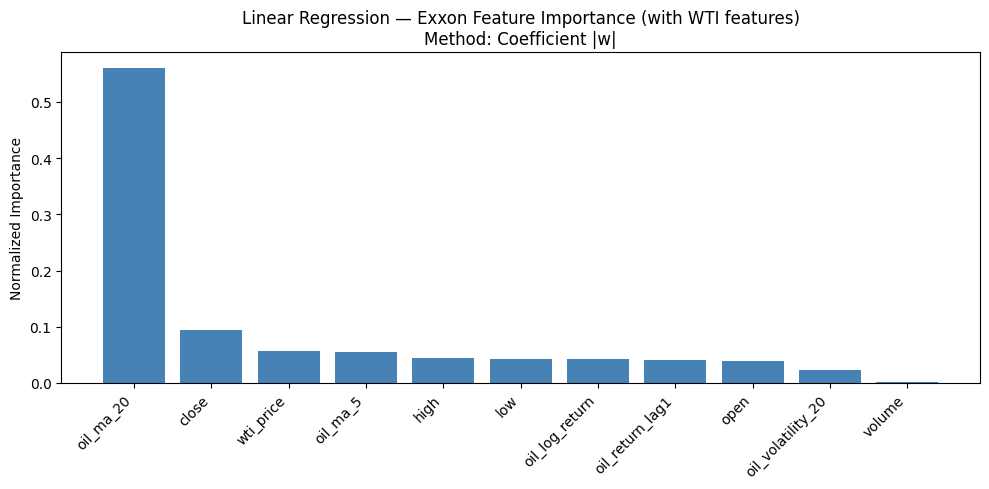

          feature  importance
        oil_ma_20    0.560418
            close    0.094711
        wti_price    0.056891
         oil_ma_5    0.054921
             high    0.043658
              low    0.042098
   oil_log_return    0.042072
  oil_return_lag1    0.041139
             open    0.039160
oil_volatility_20    0.022600
           volume    0.002332


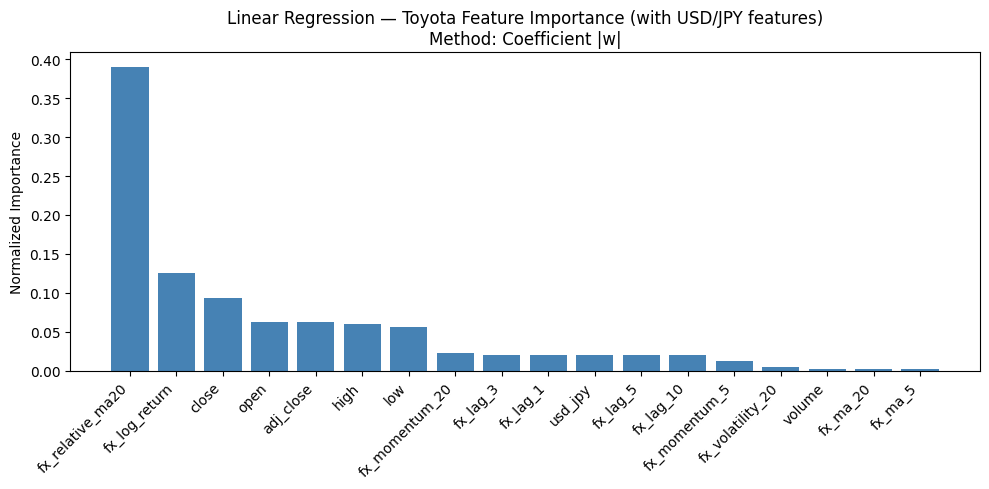

         feature  importance
fx_relative_ma20    0.389597
   fx_log_return    0.125910
           close    0.093531
            open    0.063102
       adj_close    0.062817
            high    0.059635
             low    0.055791
  fx_momentum_20    0.023367
        fx_lag_3    0.020795
        fx_lag_1    0.020539
         usd_jpy    0.020292
        fx_lag_5    0.020071
       fx_lag_10    0.020010
   fx_momentum_5    0.012526
fx_volatility_20    0.005214
          volume    0.002502
        fx_ma_20    0.002229
         fx_ma_5    0.002074


,feature,importance
0,fx_relative_ma20,0.389597
1,fx_log_return,0.125910
2,close,0.093531
3,open,0.063102
4,adj_close,0.062817
5,high,0.059635
6,low,0.055791
7,fx_momentum_20,0.023367
8,fx_lag_3,0.020795
9,fx_lag_1,0.020539


In [65]:
# Linear Regression — Exxon (merged with WTI features)
analyze_feature_importance(
    model=results_merged["last_fold_model"],
    X_te=results_merged["last_fold_X_te"],
    y_te=results_merged["last_fold_y_te"],
    feature_names=results_merged["feature_names"],
    window_size=window_size,
    title="Linear Regression — Exxon Feature Importance (with WTI features)",
)

# Linear Regression — Toyota (merged with USD/JPY features)
analyze_feature_importance(
    model=results_toyota_merged["last_fold_model"],
    X_te=results_toyota_merged["last_fold_X_te"],
    y_te=results_toyota_merged["last_fold_y_te"],
    feature_names=results_toyota_merged["feature_names"],
    window_size=window_size,
    title="Linear Regression — Toyota Feature Importance (with USD/JPY features)",
)

#### Random Forest Feature Importance

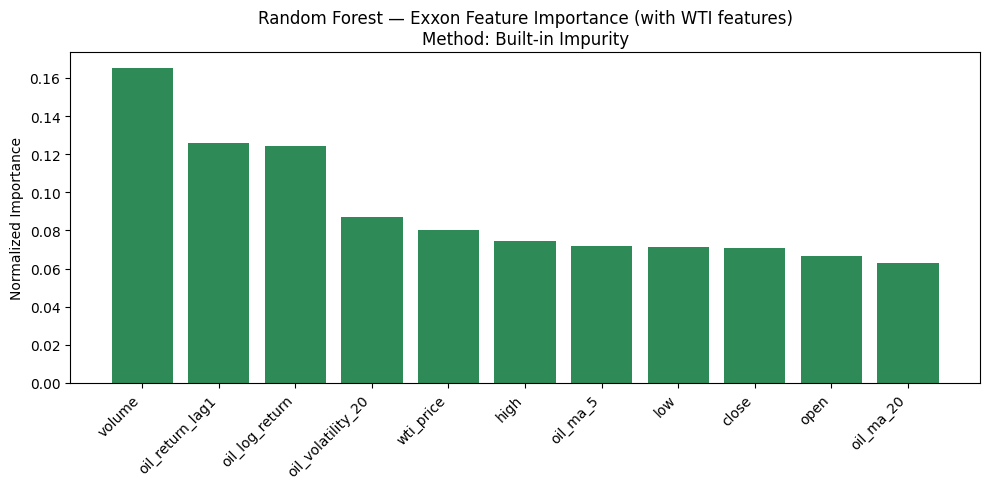

          feature  importance
           volume    0.165301
  oil_return_lag1    0.125812
   oil_log_return    0.124465
oil_volatility_20    0.086948
        wti_price    0.080062
             high    0.074538
         oil_ma_5    0.071717
              low    0.071170
            close    0.070556
             open    0.066558
        oil_ma_20    0.062875


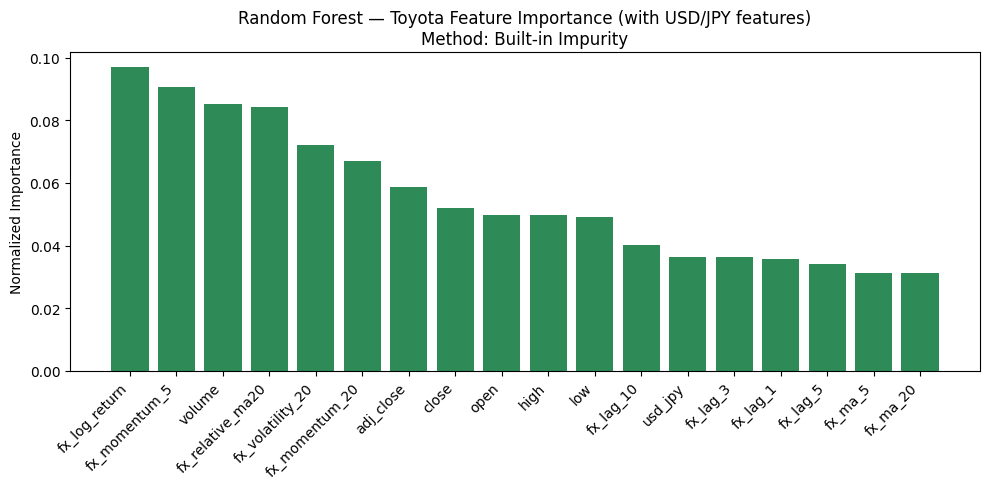

         feature  importance
   fx_log_return    0.096930
   fx_momentum_5    0.090482
          volume    0.085074
fx_relative_ma20    0.084095
fx_volatility_20    0.072145
  fx_momentum_20    0.067031
       adj_close    0.058593
           close    0.051988
            open    0.049881
            high    0.049848
             low    0.049103
       fx_lag_10    0.040079
         usd_jpy    0.036402
        fx_lag_3    0.036191
        fx_lag_1    0.035587
        fx_lag_5    0.033976
         fx_ma_5    0.031314
        fx_ma_20    0.031281


,feature,importance
0,fx_log_return,0.096930
1,fx_momentum_5,0.090482
2,volume,0.085074
3,fx_relative_ma20,0.084095
4,fx_volatility_20,0.072145
5,fx_momentum_20,0.067031
6,adj_close,0.058593
7,close,0.051988
8,open,0.049881
9,high,0.049848


In [66]:
# Random Forest — Exxon (merged)
analyze_feature_importance(
    model=results_exxon_merged_rf["last_fold_model"],
    X_te=results_exxon_merged_rf["last_fold_X_te"],
    y_te=results_exxon_merged_rf["last_fold_y_te"],
    feature_names=list(merged_exxon_df.columns),
    window_size=window_size,
    title="Random Forest — Exxon Feature Importance (with WTI features)",
    color="seagreen"
)

# Random Forest — Toyota (merged)
analyze_feature_importance(
    model=results_toyota_merged_rf["last_fold_model"],
    X_te=results_toyota_merged_rf["last_fold_X_te"],
    y_te=results_toyota_merged_rf["last_fold_y_te"],
    feature_names=list(merged_toyota_df.columns),
    window_size=window_size,
    title="Random Forest — Toyota Feature Importance (with USD/JPY features)",
    color="seagreen"
)

### Group 2: SARIMA/SARIMAX

SARIMA is excluded from the unified function because it's architecturally incompatible. It uses raw time series rather than sliding windows, it's a statsmodels object with no coef_ or feature_importances_, and its notion of importance (statistical significance of exogenous regressors) is a different concept entirely from the others. Therefore, a separate function is needed.

In [67]:
# Extracts p-values and coefficients for exogenous regressors from a  fitted SARIMAX model
# Only meaningful when exog features were passed (e.g. the merged datasets for Exxon and Toyota).
def analyze_sarimax_importance(fit_result, exog_feature_names,
                                title="SARIMAX Exogenous Feature Importance"):

    params = fit_result.params
    pvalues = fit_result.pvalues

    # Filter to only the exogenous regressors
    available = [f for f in exog_feature_names if f in params.index]

    df_exog = pd.DataFrame({
        "feature": available,
        "coefficient": params[available].values,
        "p_value": pvalues[available].values,
    })
    df_exog["significant"] = df_exog["p_value"] < 0.05
    df_exog = df_exog.sort_values("p_value").reset_index(drop=True)

    # Plot: color bars by significance
    colors = ["seagreen" if s else "lightcoral" for s in df_exog["significant"]]
    plt.figure(figsize=(10, 5))
    plt.bar(df_exog["feature"], np.abs(df_exog["coefficient"]), color=colors)
    plt.title(f"{title}\nGreen = significant (p<0.05), Red = not significant")
    plt.ylabel("|Coefficient|")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(df_exog.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    return df_exog

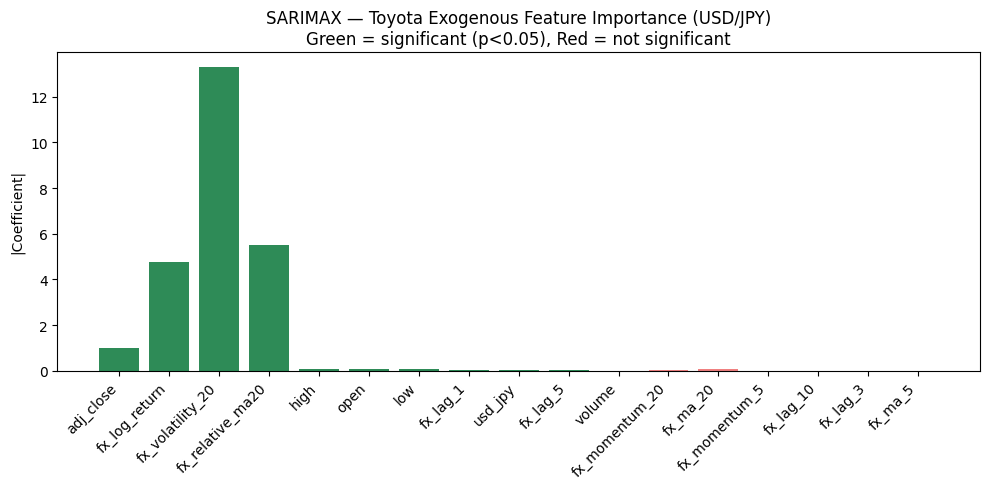

         feature  coefficient  p_value  significant
       adj_close     1.013215 0.000000         True
   fx_log_return     4.774169 0.000000         True
fx_volatility_20    13.291546 0.000000         True
fx_relative_ma20    -5.516362 0.000000         True
            high     0.079584 0.000000         True
            open    -0.061540 0.000000         True
             low     0.081412 0.000000         True
        fx_lag_1     0.029267 0.000076         True
         usd_jpy     0.020341 0.011799         True
        fx_lag_5     0.014816 0.018339         True
          volume    -0.000000 0.021425         True
  fx_momentum_20     0.010345 0.142827        False
        fx_ma_20    -0.053963 0.146571        False
   fx_momentum_5     0.005525 0.189015        False
       fx_lag_10    -0.004653 0.572610        False
        fx_lag_3    -0.003390 0.741966        False
         fx_ma_5    -0.000983 0.970081        False


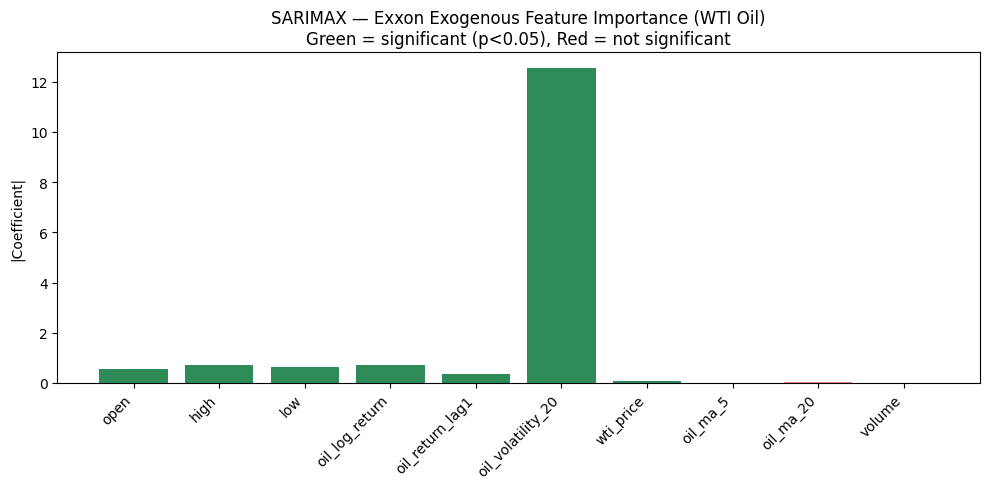

          feature  coefficient  p_value  significant
             open    -0.548057 0.000000         True
             high     0.715285 0.000000         True
              low     0.640813 0.000000         True
   oil_log_return     0.733537 0.000000         True
  oil_return_lag1    -0.345045 0.000000         True
oil_volatility_20   -12.542946 0.000000         True
        wti_price     0.060278 0.000000         True
         oil_ma_5    -0.018170 0.068925        False
        oil_ma_20     0.025892 0.109767        False
           volume    -0.000000 0.377041        False


In [68]:

# Toyota SARIMAX — USD/JPY exog features
target_col = "close"
exog_cols = [c for c in merged_toyota_df.columns if c != target_col]
_ = analyze_sarimax_importance(
    fit_result=results_toyota_sarima["last_fold_fit"],
    exog_feature_names=exog_cols,
    title="SARIMAX — Toyota Exogenous Feature Importance (USD/JPY)"
)

# Exxon SARIMAX — WTI oil exog features
exog_cols = [c for c in merged_exxon_df.columns if c != target_col]
_ = analyze_sarimax_importance(
    fit_result=results_exxon_sarima["last_fold_fit"],
    exog_feature_names=exog_cols,
    title="SARIMAX — Exxon Exogenous Feature Importance (WTI Oil)"
)